# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [4]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports for modeling and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Added for Ridge Regression RMSE calculation
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from collections import Counter  # For spec feature engineering

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


#### **1.1.1**
Load the dataset

In [5]:
# Load the data
df = pd.read_csv('Car_Price_data.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("First few rows:")
print(df.head())
print("\n" + "="*80)
print("Dataset Info:")
print(df.info())
print("\n" + "="*80)
print("Statistical Summary:")
print(df.describe())

Dataset Shape: (15915, 23)

First few rows:
  make_model body_type  price               vat       km  Type     Fuel  \
0    Audi A1    Sedans  15770    VAT deductible  56013.0  Used   Diesel   
1    Audi A1    Sedans  14500  Price negotiable  80000.0  Used  Benzine   
2    Audi A1    Sedans  14640    VAT deductible  83450.0  Used   Diesel   
3    Audi A1    Sedans  14500    VAT deductible  73000.0  Used   Diesel   
4    Audi A1    Sedans  16790    VAT deductible  16200.0  Used   Diesel   

   Gears                                Comfort_Convenience  \
0    7.0  Air conditioning,Armrest,Automatic climate con...   
1    7.0  Air conditioning,Automatic climate control,Hil...   
2    7.0  Air conditioning,Cruise control,Electrical sid...   
3    6.0  Air suspension,Armrest,Auxiliary heating,Elect...   
4    7.0  Air conditioning,Armrest,Automatic climate con...   

                                 Entertainment_Media  ... Previous_Owners  \
0  Bluetooth,Hands-free equipment,On-board comput

## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [6]:
# Find the proportion of missing values in each column and handle if found

# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a dataframe to display missing values clearly
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print("Missing Values Summary:")
print("=" * 80)
if len(missing_df) == 0:
    print("✓ No missing values found in the dataset!")
else:
    print(missing_df.to_string(index=False))
    print("\nHandling missing values...")
    
    # For numerical columns with missing values: fill with median
    numerical_missing = df.select_dtypes(include=[np.number]).columns[df.select_dtypes(include=[np.number]).isnull().any()]
    for col in numerical_missing:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  • {col}: Filled with median = {median_val}")
    
    # For categorical columns with missing values: fill with mode
    categorical_missing = df.select_dtypes(include=['object']).columns[df.select_dtypes(include=['object']).isnull().any()]
    for col in categorical_missing:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  • {col}: Filled with mode = {mode_val}")
    
    print("\nMissing values after handling:")
    print(df.isnull().sum().sum(), "missing values remaining")

print("\n" + "=" * 80)
print("Dataset shape after handling missing values:", df.shape)

Missing Values Summary:
✓ No missing values found in the dataset!

Dataset shape after handling missing values: (15915, 23)


**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

Numerical Features Identified:
['price', 'km', 'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Displacement_cc', 'Weight_kg', 'cons_comb']

Total Numerical Features: 10

Statistical Summary of Numerical Features:
                   count          mean           std     min      25%  \
price            15915.0  18024.380584   7381.679318  4950.0  12850.0   
km               15915.0  32089.995708  36977.214964     0.0   1920.5   
Gears            15915.0      5.937355      0.704772     5.0      5.0   
age              15915.0      1.389695      1.121306     0.0      0.0   
Previous_Owners  15915.0      1.042853      0.339178     0.0      1.0   
hp_kW            15915.0     88.499340     26.674341    40.0     66.0   
Inspection_new   15915.0      0.247063      0.431317     0.0      0.0   
Displacement_cc  15915.0   1428.661891    275.804272   890.0   1229.0   
Weight_kg        15915.0   1337.700534    199.682385   840.0   1165.0   
cons_comb        15915.0      4.832124    

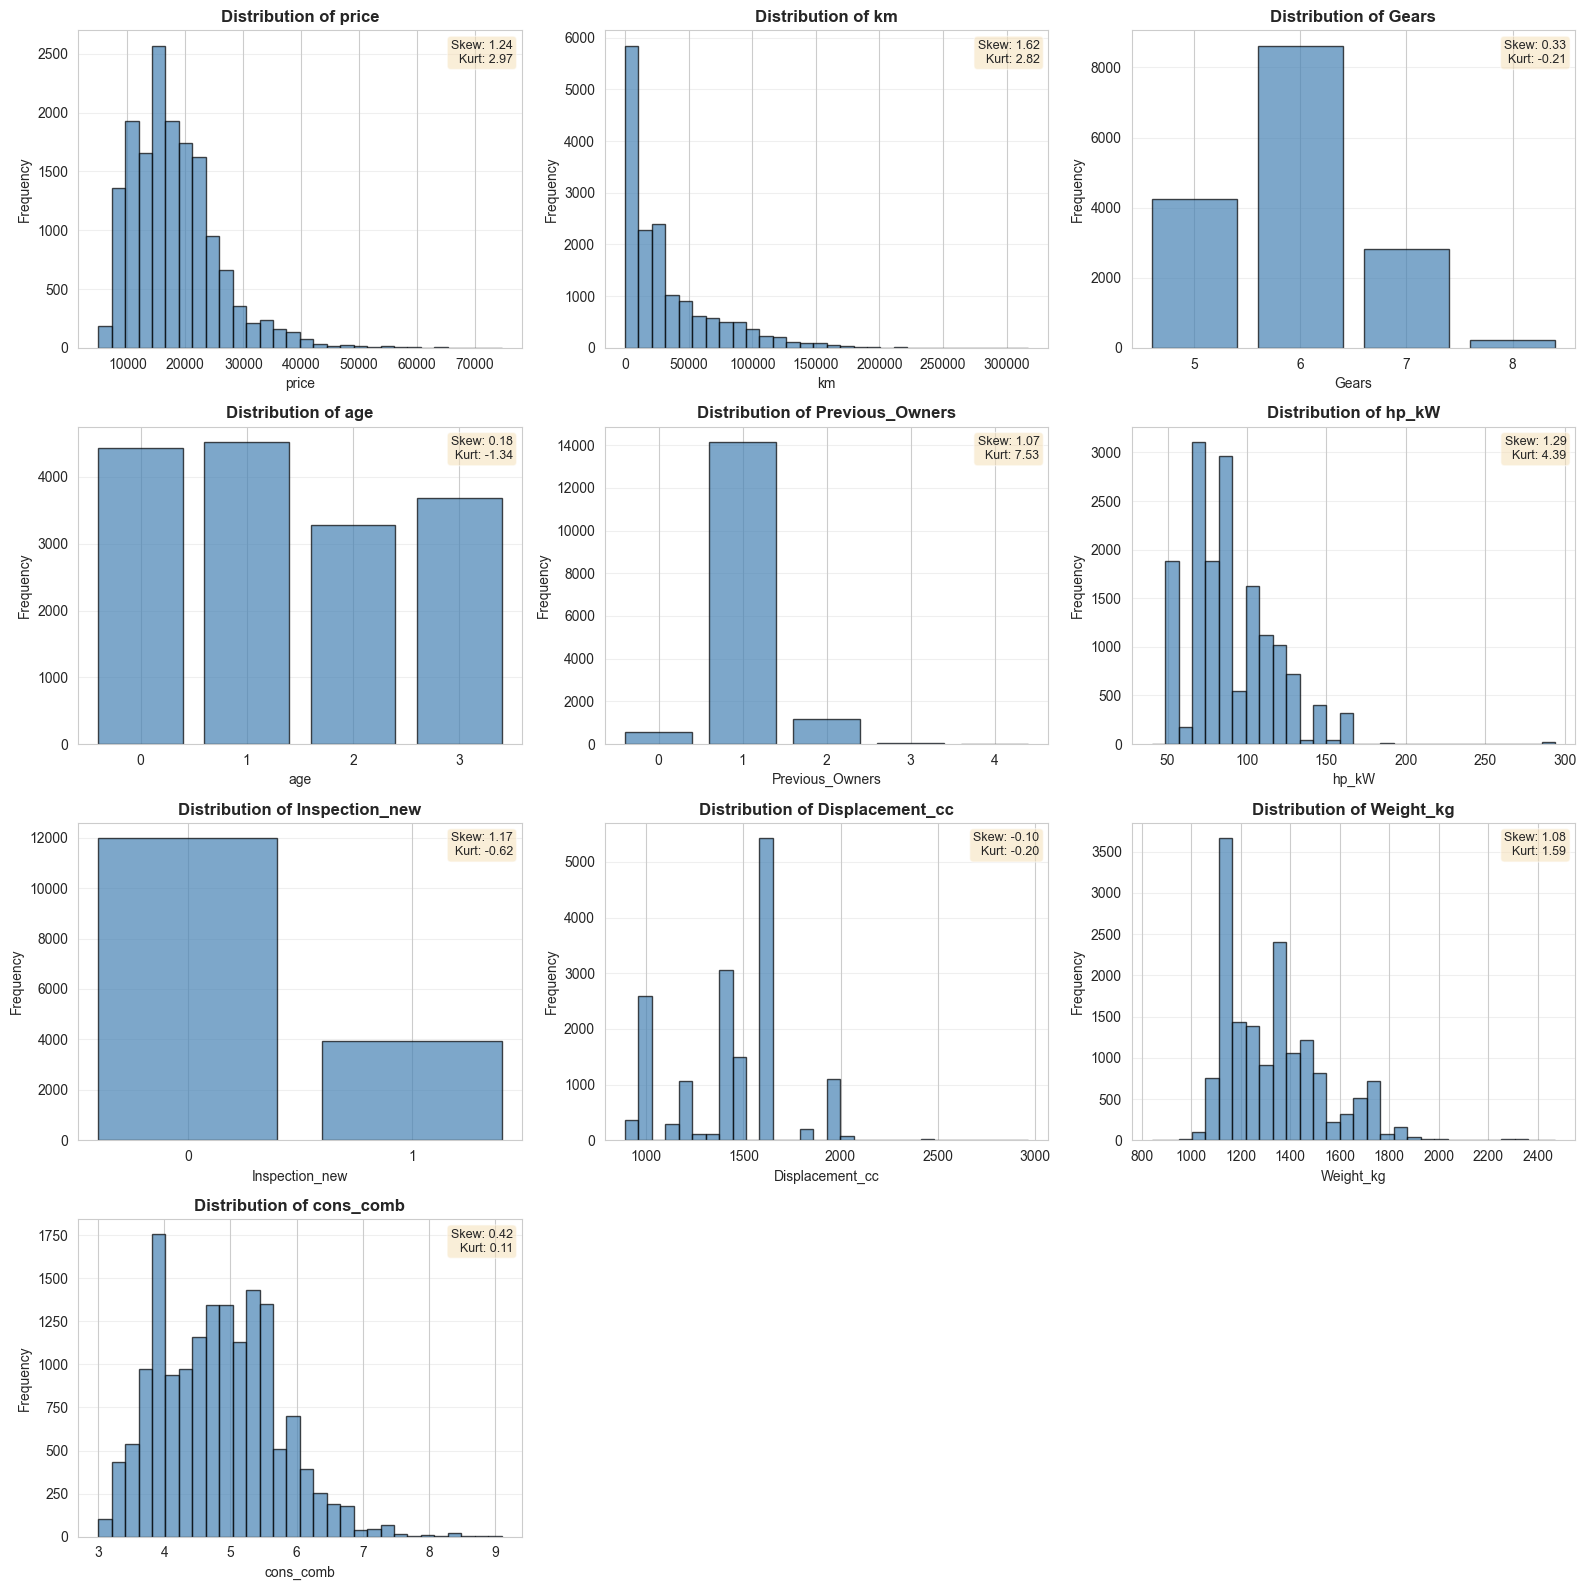

Saved: images/numerical_features_histograms.png

Observations from Numerical Feature Distributions:

price:
  • Skewness: 1.236 (Right-skewed)
  • Kurtosis: 2.966
  • Range: [4950.00, 74600.00]

km:
  • Skewness: 1.623 (Right-skewed)
  • Kurtosis: 2.825
  • Range: [0.00, 317000.00]

Gears:
  • Skewness: 0.331 (Fairly symmetric)
  • Kurtosis: -0.213
  • Range: [5.00, 8.00]

age:
  • Skewness: 0.176 (Fairly symmetric)
  • Kurtosis: -1.337
  • Range: [0.00, 3.00]

Previous_Owners:
  • Skewness: 1.075 (Right-skewed)
  • Kurtosis: 7.531
  • Range: [0.00, 4.00]

hp_kW:
  • Skewness: 1.293 (Right-skewed)
  • Kurtosis: 4.386
  • Range: [40.00, 294.00]

Inspection_new:
  • Skewness: 1.173 (Right-skewed)
  • Kurtosis: -0.624
  • Range: [0.00, 1.00]

Displacement_cc:
  • Skewness: -0.097 (Fairly symmetric)
  • Kurtosis: -0.202
  • Range: [890.00, 2967.00]

Weight_kg:
  • Skewness: 1.082 (Right-skewed)
  • Kurtosis: 1.594
  • Range: [840.00, 2471.00]

cons_comb:
  • Skewness: 0.419 (Fairly symmetr

In [7]:
# Identify numerical features and plot histograms

# Identify numerical columns (excluding object type)
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numerical Features Identified:")
print("=" * 80)
print(numerical_features)
print(f"\nTotal Numerical Features: {len(numerical_features)}")
print("\n" + "=" * 80)
print("Statistical Summary of Numerical Features:")
print("=" * 80)
print(df[numerical_features].describe().T)

# Identify discrete vs continuous features
discrete_features = []
continuous_features = []

for feature in numerical_features:
    unique_values = df[feature].nunique()
    # If a feature has 20 or fewer unique values, treat it as discrete
    if unique_values <= 20:
        discrete_features.append(feature)
    else:
        continuous_features.append(feature)

print("\n" + "=" * 80)
print("Feature Classification:")
print("=" * 80)
print(f"Discrete Features: {discrete_features}")
print(f"Continuous Features: {continuous_features}")

# Plot frequency distributions for numerical features
n_features = len(numerical_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

for idx, feature in enumerate(numerical_features):
    if feature in discrete_features:
        # For discrete features, use bar chart
        value_counts = df[feature].value_counts().sort_index()
        axes[idx].bar(value_counts.index, value_counts.values, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_xticks(sorted(df[feature].unique()))
    else:
        # For continuous features, use histogram
        axes[idx].hist(df[feature], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)
    # Add skewness and kurtosis information
    skewness = df[feature].skew()
    kurtosis = df[feature].kurtosis()
    axes[idx].text(0.98, 0.97, f'Skew: {skewness:.2f}\nKurt: {kurtosis:.2f}', 
                   transform=axes[idx].transAxes, verticalalignment='top', 
                   horizontalalignment='right', bbox=dict(boxstyle='round', 
                   facecolor='wheat', alpha=0.5), fontsize=9)

# Remove extra subplots
for idx in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('images/numerical_features_histograms.png', dpi=150)
plt.show()
print("Saved: images/numerical_features_histograms.png")

print("\n" + "=" * 80)
print("Observations from Numerical Feature Distributions:")
print("=" * 80)
for feature in numerical_features:
    skew = df[feature].skew()
    kurt = df[feature].kurtosis()
    # Determine skewness label
    if skew > 0.5:
        skew_label = "(Right-skewed)"
    elif skew < -0.5:
        skew_label = "(Left-skewed)"
    else:
        skew_label = "(Fairly symmetric)"
    print(f"\n{feature}:")
    print(f"  • Skewness: {skew:.3f} {skew_label}")
    print(f"  • Kurtosis: {kurt:.3f}")
    print(f"  • Range: [{df[feature].min():.2f}, {df[feature].max():.2f}]")

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

Categorical Features Identified:
['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']

Total Categorical Features: 9

Frequency Distribution of Categorical Features:

make_model:
  Unique values: 9
make_model
Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2525
Opel Corsa        2216
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1

body_type:
  Unique values: 8
body_type
Sedans           8004
Station wagon    3677
Compact          3240
Van               817
Transporter        88
Off-Road           56
Coupe              25
Convertible         8

vat:
  Unique values: 2
vat
VAT deductible      15044
Price negotiable      871

Type:
  Unique values: 5
Type
Used              11095
New                1649
Pre-registered     1364
Employee's car     1011
Demonstration       796

Fuel:
  Unique values: 4
Fuel
Benzine     8548
Diesel      7298
LPG/CNG 

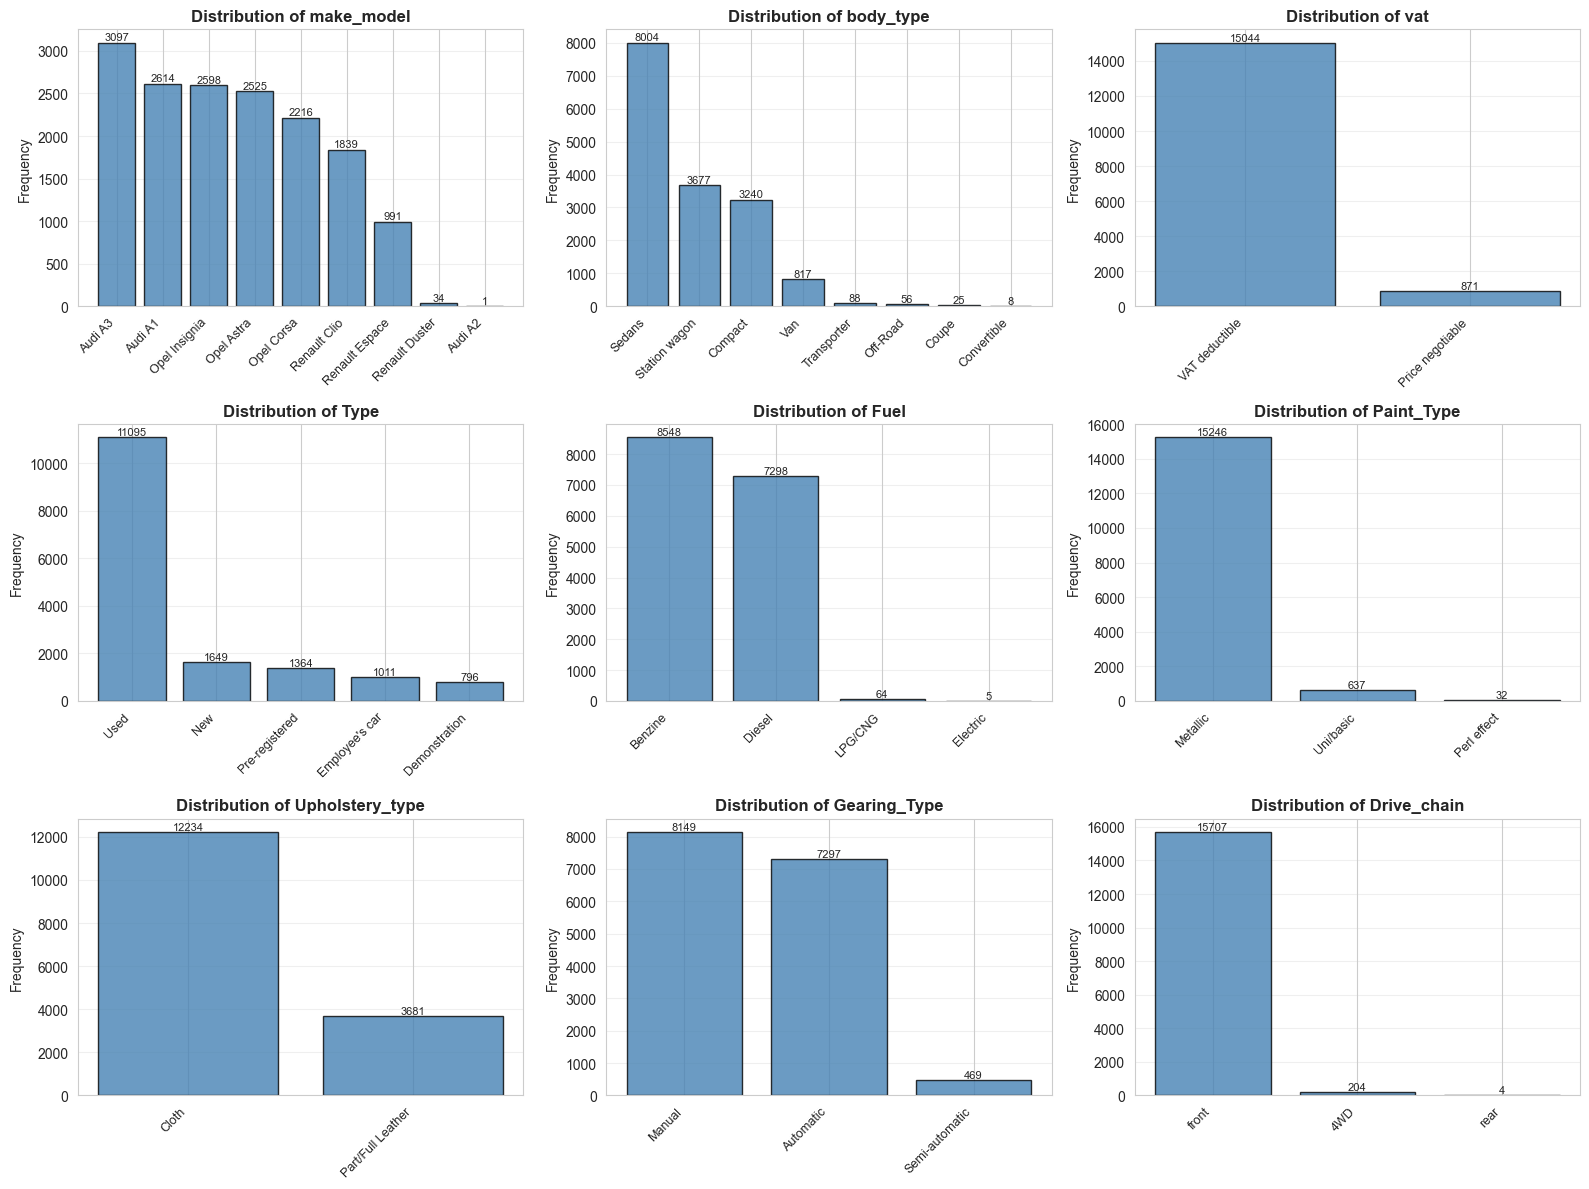

Saved: images/categorical_features_barplots.png

Summary of Categorical Features:

make_model:
  • Number of unique values: 9
  • Most frequent value: Audi A3 (count: 3097)
  • Least frequent value: Audi A2 (count: 1)
  • Class imbalance ratio (max class): 19.5%

body_type:
  • Number of unique values: 8
  • Most frequent value: Sedans (count: 8004)
  • Least frequent value: Convertible (count: 8)
  • Class imbalance ratio (max class): 50.3%

vat:
  • Number of unique values: 2
  • Most frequent value: VAT deductible (count: 15044)
  • Least frequent value: Price negotiable (count: 871)
  • Class imbalance ratio (max class): 94.5%

Type:
  • Number of unique values: 5
  • Most frequent value: Used (count: 11095)
  • Least frequent value: Demonstration (count: 796)
  • Class imbalance ratio (max class): 69.7%

Fuel:
  • Number of unique values: 4
  • Most frequent value: Benzine (count: 8548)
  • Least frequent value: Electric (count: 5)
  • Class imbalance ratio (max class): 53.7%

Pai

In [140]:
# Identify categorical columns and check their frequency distributions

# Identify categorical columns (object type)
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Exclude the feature spec columns as they contain comma-separated lists
spec_columns = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']
categorical_features = [col for col in categorical_features if col not in spec_columns]

print("Categorical Features Identified:")
print("=" * 80)
print(categorical_features)
print(f"\nTotal Categorical Features: {len(categorical_features)}")

# Display frequency distribution for each categorical feature
print("\n" + "=" * 80)
print("Frequency Distribution of Categorical Features:")
print("=" * 80)

for feature in categorical_features:
    print(f"\n{feature}:")
    print(f"  Unique values: {df[feature].nunique()}")
    print(df[feature].value_counts().to_string())

# Plot frequency distributions for categorical features
n_features = len(categorical_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    # Get value counts
    value_counts = df[feature].value_counts().sort_values(ascending=False)
    # Plot bar chart
    axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue', alpha=0.8, edgecolor='black')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)
    # Add value labels on bars
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v + 5, str(v), ha='center', va='bottom', fontsize=8)
# Remove extra subplots
for idx in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('images/categorical_features_barplots.png', dpi=150)
plt.show()
print("Saved: images/categorical_features_barplots.png")

# Print summary statistics
print("\n" + "=" * 80)
print("Summary of Categorical Features:")
print("=" * 80)
for feature in categorical_features:
    print(f"\n{feature}:")
    print(f"  • Number of unique values: {df[feature].nunique()}")
    print(f"  • Most frequent value: {df[feature].mode()[0]} (count: {df[feature].value_counts().iloc[0]})")
    print(f"  • Least frequent value: {df[feature].value_counts().index[-1]} (count: {df[feature].value_counts().iloc[-1]})")
    # Check for class imbalance
    freq_pct = (df[feature].value_counts().iloc[0] / len(df)) * 100
    print(f"  • Class imbalance ratio (max class): {freq_pct:.1f}%")

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [141]:
# Fix columns as needed

print("HANDLING CLASS IMBALANCES AND LOW FREQUENCY VALUES")
print("=" * 80)

# 1. Handle 'Type' column
print("\n1. Handling 'Type' Column:")
print("-" * 80)
print("Current value counts:")
print(df['Type'].value_counts())

# Group rare categories in Type column based on provided information:
# Pre-registered, New, Employee's car, Demonstration -> Group as "Pre-registered/New/Special"
# Used -> Keep as is

def consolidate_type(x):
    if x in ['Pre-registered', 'New', "Employee's car", 'Demonstration']:
        return 'New/Pre-registered'
    else:
        return x

df['Type'] = df['Type'].apply(consolidate_type)

print("\nAfter consolidation:")
print(df['Type'].value_counts())

# 2. Handle other categorical columns with low frequency values
print("\n" + "=" * 80)
print("2. Handling Other Categorical Columns:")
print("-" * 80)

# Define frequency threshold (5% of data)
freq_threshold = 0.05

for col in categorical_features:
    if col == 'Type':
        continue  # Already handled
    
    print(f"\n{col}:")
    value_counts = df[col].value_counts()
    freq_counts = df[col].value_counts(normalize=True)
    
    # Identify rare categories
    rare_categories = freq_counts[freq_counts < freq_threshold].index.tolist()
    
    if len(rare_categories) > 0:
        print(f"  • Rare categories (< 5%): {rare_categories}")
        print(f"  • Consolidating rare categories into 'Other'...")
        
        # Consolidate rare categories
        df[col] = df[col].apply(lambda x: 'Other' if x in rare_categories else x)
        
        print(f"  • Updated value counts:")
        print(df[col].value_counts().to_string())
    else:
        print(f"  • No rare categories found")

# 3. Summary of changes
print("\n" + "=" * 80)
print("3. Summary of Changes:")
print("=" * 80)
print("\nUpdated categorical feature distributions:")

for feature in categorical_features:
    value_counts = df[feature].value_counts()
    print(f"\n{feature}:")
    print(f"  • Number of categories: {len(value_counts)}")
    print(f"  • Category distribution: {value_counts.to_dict()}")

print("\n" + "=" * 80)
print("Dataset shape after handling imbalances:", df.shape)
print("=" * 80)

HANDLING CLASS IMBALANCES AND LOW FREQUENCY VALUES

1. Handling 'Type' Column:
--------------------------------------------------------------------------------
Current value counts:
Type
Used              11095
New                1649
Pre-registered     1364
Employee's car     1011
Demonstration       796
Name: count, dtype: int64

After consolidation:
Type
Used                  11095
New/Pre-registered     4820
Name: count, dtype: int64

2. Handling Other Categorical Columns:
--------------------------------------------------------------------------------

make_model:
  • Rare categories (< 5%): ['Renault Duster', 'Audi A2']
  • Consolidating rare categories into 'Other'...
  • Updated value counts:
make_model
Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2525
Opel Corsa        2216
Renault Clio      1839
Renault Espace     991
Other               35

body_type:
  • Rare categories (< 5%): ['Transporter', 'Off-Road', 'Coupe', 'Convertible']
  •

#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

Target variable: price
count    15915.000000
mean     18024.380584
std       7381.679318
min       4950.000000
25%      12850.000000
50%      16900.000000
75%      21900.000000
max      74600.000000
Name: price, dtype: float64


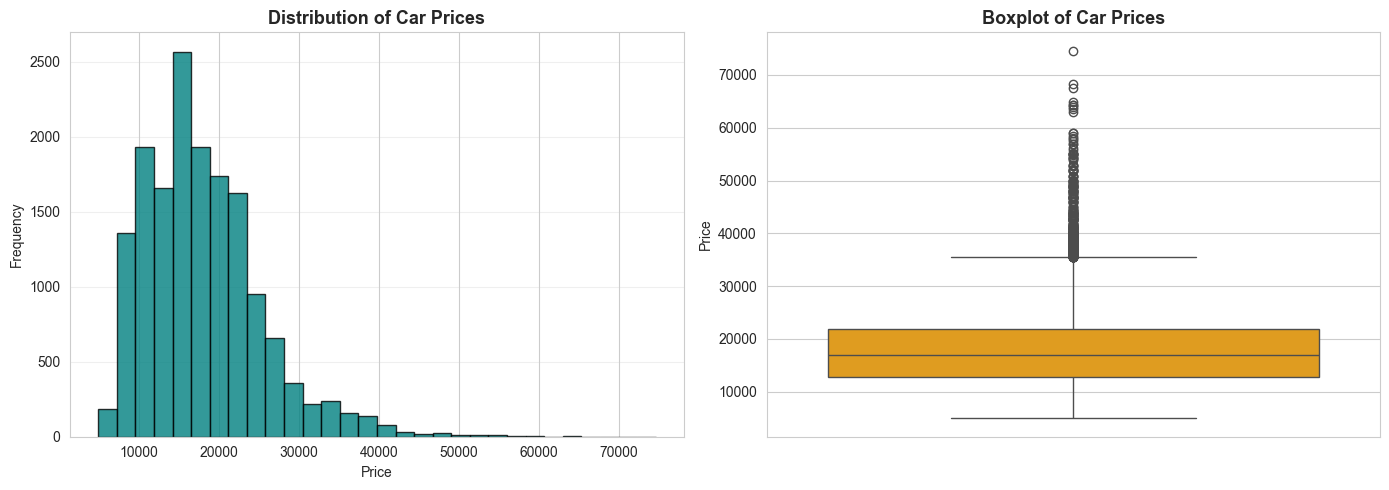

Saved: images/price_distribution_and_boxplot.png
Skewness: 1.236
Kurtosis: 2.966
The target variable is right-skewed. A log transformation is recommended.

Applied log1p transformation to the target variable. New column: 'log_price'


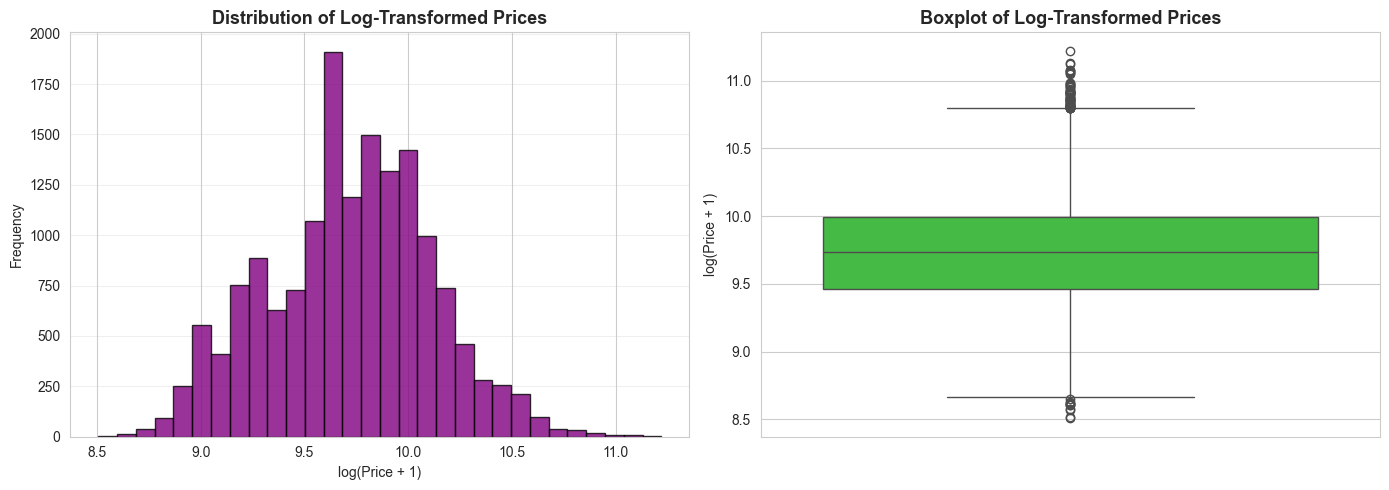

Saved: images/log_price_distribution_and_boxplot.png
Log-Transformed Skewness: -0.031
Log-Transformed Kurtosis: -0.240


In [142]:
# Plot histograms for target feature

# 1. Identify the target variable
target = 'price'

print(f"Target variable: {target}")
print("=" * 80)
print(df[target].describe())

# 2. Plot histogram and boxplot for the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[target], bins=30, color='teal', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Car Prices', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
sns.boxplot(y=df[target], ax=axes[1], color='orange')
axes[1].set_title('Boxplot of Car Prices', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.savefig('images/price_distribution_and_boxplot.png', dpi=150)
plt.show()
print("Saved: images/price_distribution_and_boxplot.png")

# 3. Check skewness and kurtosis
skew = df[target].skew()
kurt = df[target].kurtosis()
print(f"Skewness: {skew:.3f}")
print(f"Kurtosis: {kurt:.3f}")

if skew > 0.5:
    print("The target variable is right-skewed. A log transformation is recommended.")
elif skew < -0.5:
    print("The target variable is left-skewed. Consider a transformation.")
else:
    print("The target variable is fairly symmetric.")

# 4. Apply log transformation if skewed
if skew > 0.5:
    df['log_price'] = np.log1p(df[target])
    print("\nApplied log1p transformation to the target variable. New column: 'log_price'")
    # Plot transformed distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df['log_price'], bins=30, color='purple', edgecolor='black', alpha=0.8)
    axes[0].set_title('Distribution of Log-Transformed Prices', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('log(Price + 1)')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(axis='y', alpha=0.3)
    sns.boxplot(y=df['log_price'], ax=axes[1], color='limegreen')
    axes[1].set_title('Boxplot of Log-Transformed Prices', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('log(Price + 1)')
    plt.tight_layout()
    plt.savefig('images/log_price_distribution_and_boxplot.png', dpi=150)
    plt.show()
    print("Saved: images/log_price_distribution_and_boxplot.png")
    print(f"Log-Transformed Skewness: {df['log_price'].skew():.3f}")
    print(f"Log-Transformed Kurtosis: {df['log_price'].kurtosis():.3f}")
else:
    print("No transformation applied to the target variable.")

**The target variable seems to be skewed. Perform suitable transformation on the target.**

Comparing original and log-transformed target variable:
Original price stats:
count    15915.000000
mean     18024.380584
std       7381.679318
min       4950.000000
25%      12850.000000
50%      16900.000000
75%      21900.000000
max      74600.000000
Name: price, dtype: float64

Log-transformed price stats:
count    15915.000000
mean         9.720764
std          0.398222
min          8.507345
25%          9.461177
50%          9.735128
75%          9.994288
max         11.219909
Name: log_price, dtype: float64


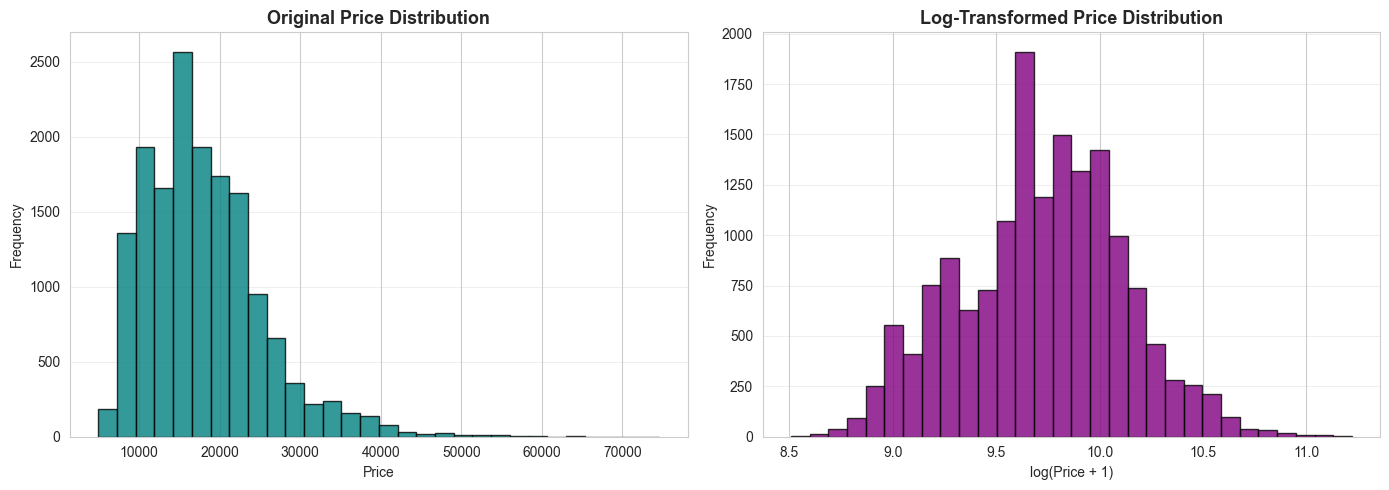

Saved: images/price_vs_log_price_hist.png
Original Skewness: 1.236, Kurtosis: 2.966
Log-Transformed Skewness: -0.031, Kurtosis: -0.240


In [143]:
# Transform the target feature

# If log transformation was applied, compare original and transformed target visually and statistically
if 'log_price' in df.columns:
    print("Comparing original and log-transformed target variable:")
    print("=" * 80)
    print("Original price stats:")
    print(df['price'].describe())
    print("\nLog-transformed price stats:")
    print(df['log_price'].describe())
    
    # Plot side-by-side histograms
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df['price'], bins=30, color='teal', edgecolor='black', alpha=0.8)
    axes[0].set_title('Original Price Distribution', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Price')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(axis='y', alpha=0.3)
    
    axes[1].hist(df['log_price'], bins=30, color='purple', edgecolor='black', alpha=0.8)
    axes[1].set_title('Log-Transformed Price Distribution', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('log(Price + 1)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('images/price_vs_log_price_hist.png', dpi=150)
    plt.show()
    print("Saved: images/price_vs_log_price_hist.png")
    
    # Print skewness and kurtosis for both
    print(f"Original Skewness: {df['price'].skew():.3f}, Kurtosis: {df['price'].kurtosis():.3f}")
    print(f"Log-Transformed Skewness: {df['log_price'].skew():.3f}, Kurtosis: {df['log_price'].kurtosis():.3f}")
else:
    print("No log transformation was applied. Nothing to compare.")

### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

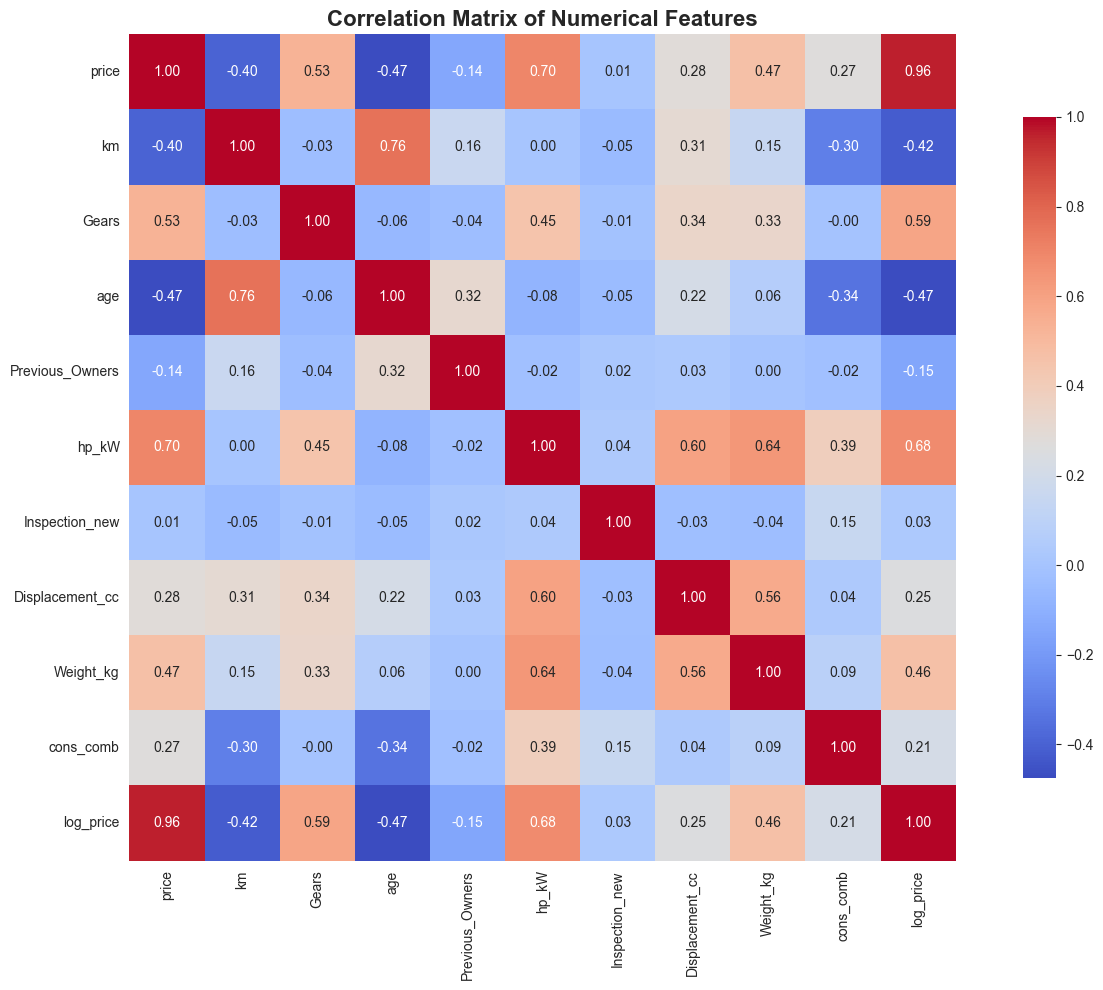

Saved: images/correlation_matrix.png
Top correlations with target variable (log_price):
price              0.962281
hp_kW              0.678024
Gears              0.588194
age               -0.474618
Weight_kg          0.464597
km                -0.419189
Displacement_cc    0.254854
cons_comb          0.211097
Previous_Owners   -0.152029
Inspection_new     0.030927
Name: log_price, dtype: float64


In [144]:
# Visualise correlation

# Use log_price if it exists, else use price as target
target_col = 'log_price' if 'log_price' in df.columns else 'price'

# Select only numerical features for correlation
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col not in numerical_features:
    numerical_features.append(target_col)

corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_matrix.png', dpi=150)
plt.show()
print("Saved: images/correlation_matrix.png")

# Show top correlations with the target variable
print("Top correlations with target variable ({}):".format(target_col))
target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print(target_corr)

#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

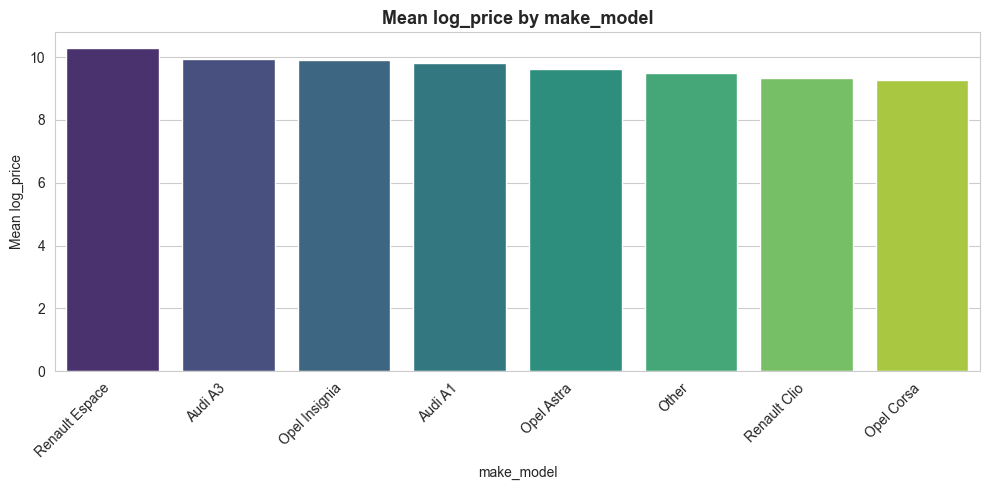

Saved: images/mean_log_price_by_make_model.png

Mean log_price by make_model:
make_model
Renault Espace    10.271724
Audi A3            9.928165
Opel Insignia      9.912658
Audi A1            9.817643
Opel Astra         9.626041
Other              9.504893
Renault Clio       9.335822
Opel Corsa         9.276059
Name: log_price, dtype: float64


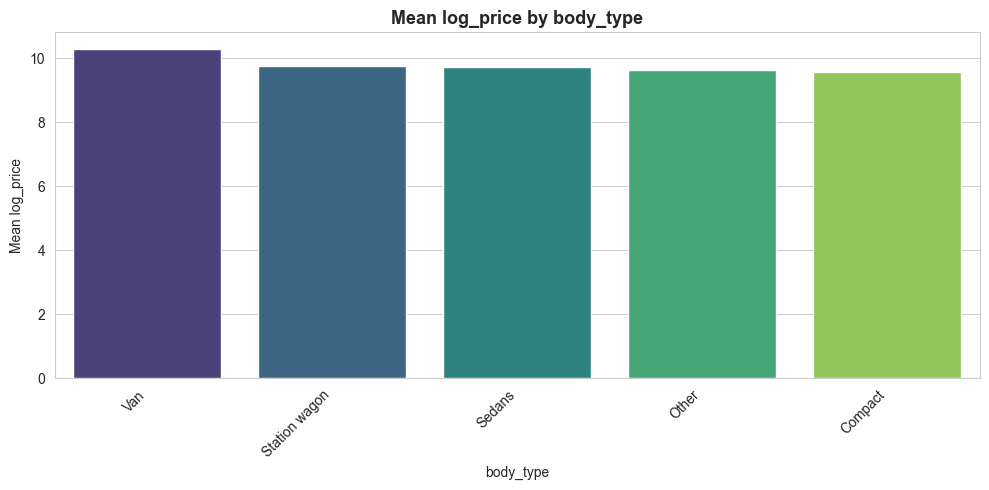

Saved: images/mean_log_price_by_body_type.png

Mean log_price by body_type:
body_type
Van              10.294540
Station wagon     9.753456
Sedans            9.716144
Other             9.622932
Compact           9.555735
Name: log_price, dtype: float64


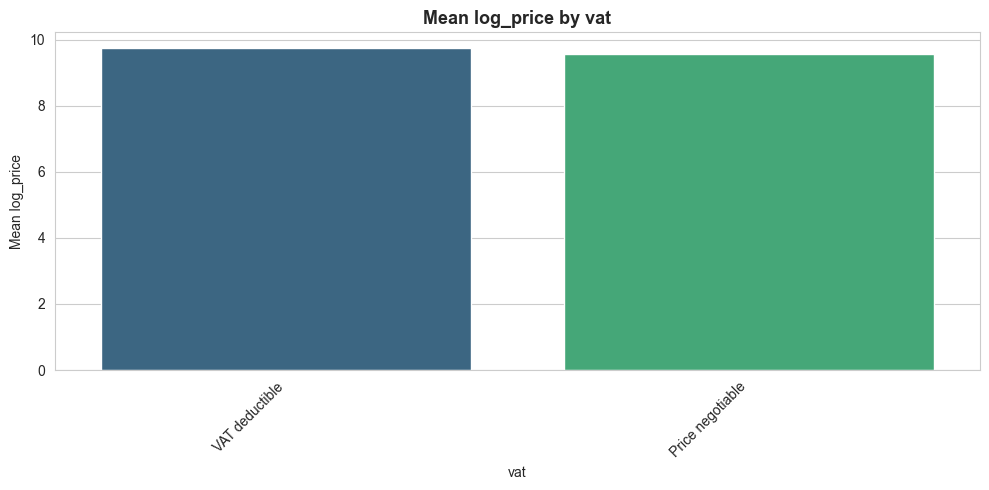

Saved: images/mean_log_price_by_vat.png

Mean log_price by vat:
vat
VAT deductible      9.730286
Price negotiable    9.556299
Name: log_price, dtype: float64


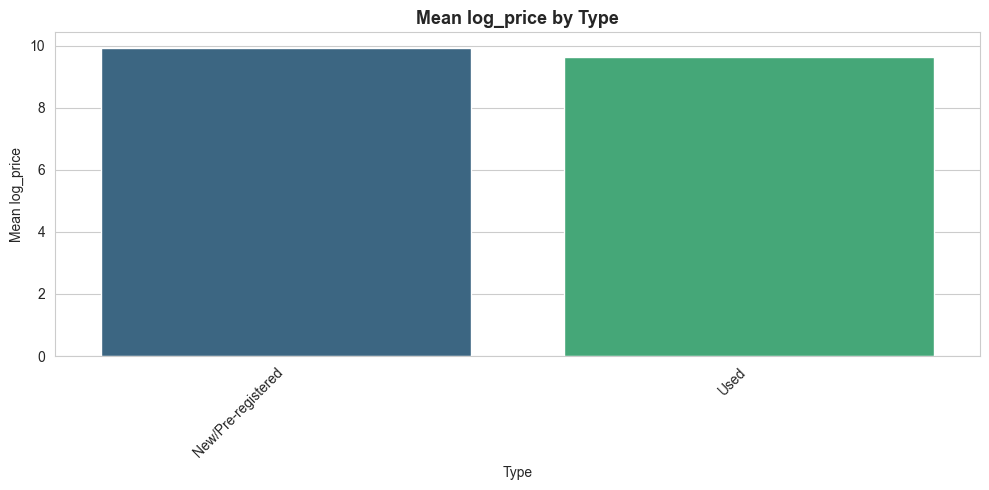

Saved: images/mean_log_price_by_Type.png

Mean log_price by Type:
Type
New/Pre-registered    9.928387
Used                  9.630566
Name: log_price, dtype: float64


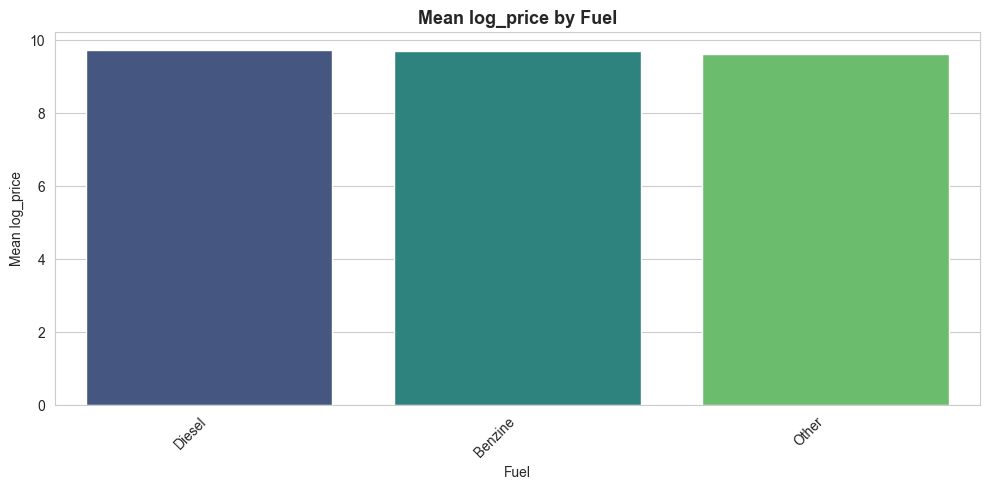

Saved: images/mean_log_price_by_Fuel.png

Mean log_price by Fuel:
Fuel
Diesel     9.734926
Benzine    9.709328
Other      9.639463
Name: log_price, dtype: float64


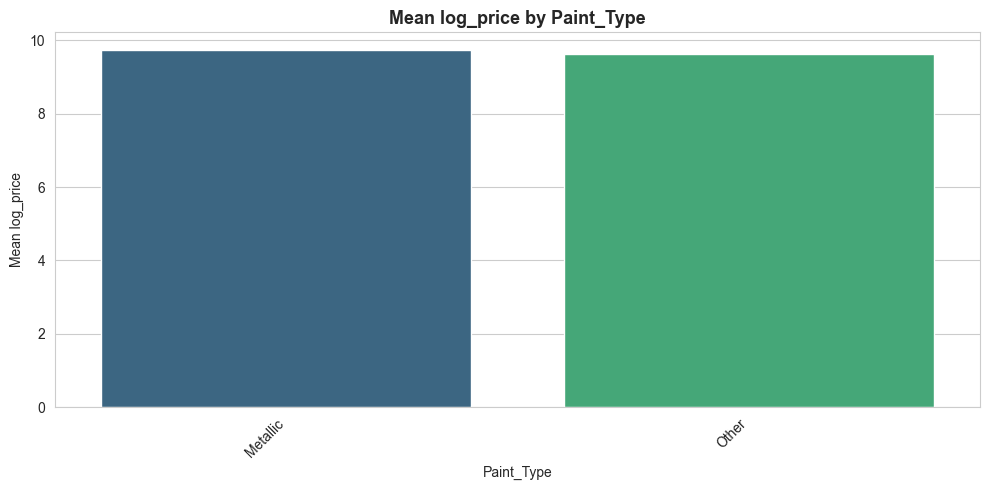

Saved: images/mean_log_price_by_Paint_Type.png

Mean log_price by Paint_Type:
Paint_Type
Metallic    9.725404
Other       9.615009
Name: log_price, dtype: float64


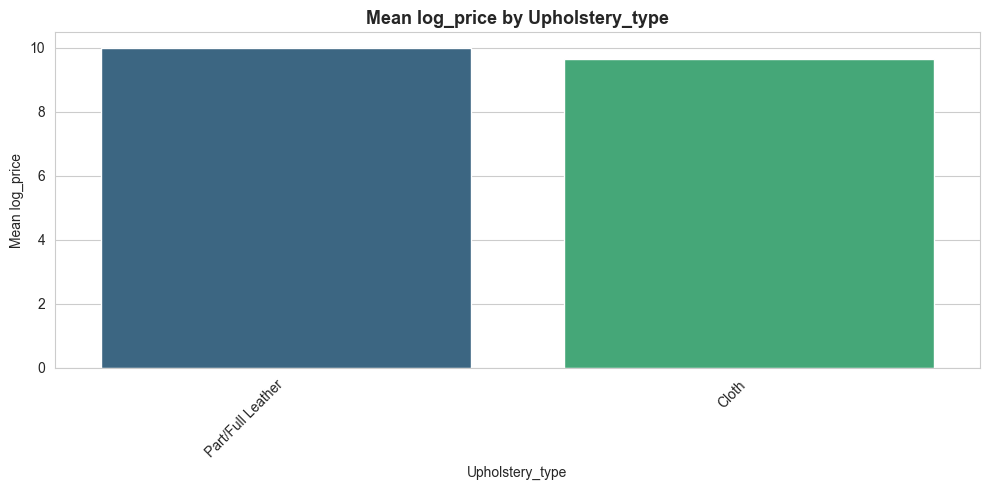

Saved: images/mean_log_price_by_Upholstery_type.png

Mean log_price by Upholstery_type:
Upholstery_type
Part/Full Leather    9.981383
Cloth                9.642348
Name: log_price, dtype: float64


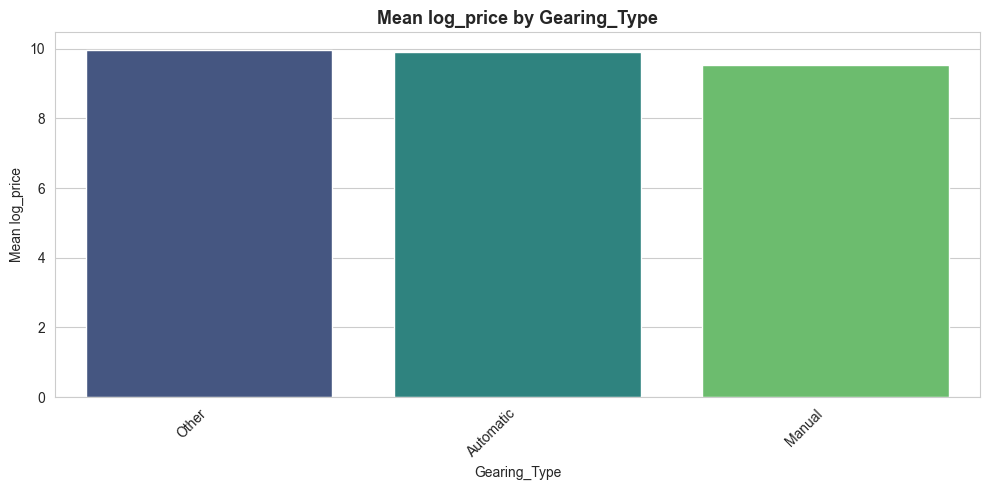

Saved: images/mean_log_price_by_Gearing_Type.png

Mean log_price by Gearing_Type:
Gearing_Type
Other        9.972004
Automatic    9.906177
Manual       9.540276
Name: log_price, dtype: float64


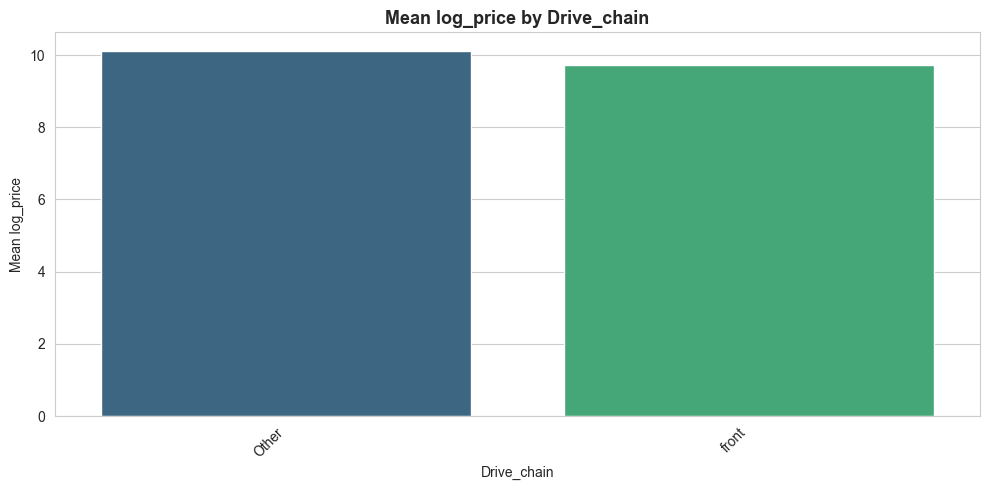

Saved: images/mean_log_price_by_Drive_chain.png

Mean log_price by Drive_chain:
Drive_chain
Other    10.123350
front     9.715432
Name: log_price, dtype: float64


In [145]:
# Comparing average values of target for different categories

# Use log_price if it exists, else use price as target
target_col = 'log_price' if 'log_price' in df.columns else 'price'

# List of categorical features (excluding spec columns)
spec_columns = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features = [col for col in categorical_features if col not in spec_columns]

# Plot mean target value for each category in each categorical feature
for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    order = df.groupby(feature)[target_col].mean().sort_values(ascending=False).index
    sns.barplot(x=feature, y=target_col, data=df, order=order, ci=None, palette='viridis')
    plt.title(f'Mean {target_col} by {feature}', fontsize=13, fontweight='bold')
    plt.ylabel(f'Mean {target_col}')
    plt.xlabel(feature)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    fname = f'images/mean_{target_col}_by_{feature}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")
    # Print group means
    print(f"\nMean {target_col} by {feature}:")
    print(df.groupby(feature)[target_col].mean().sort_values(ascending=False))
    print("="*80)

### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

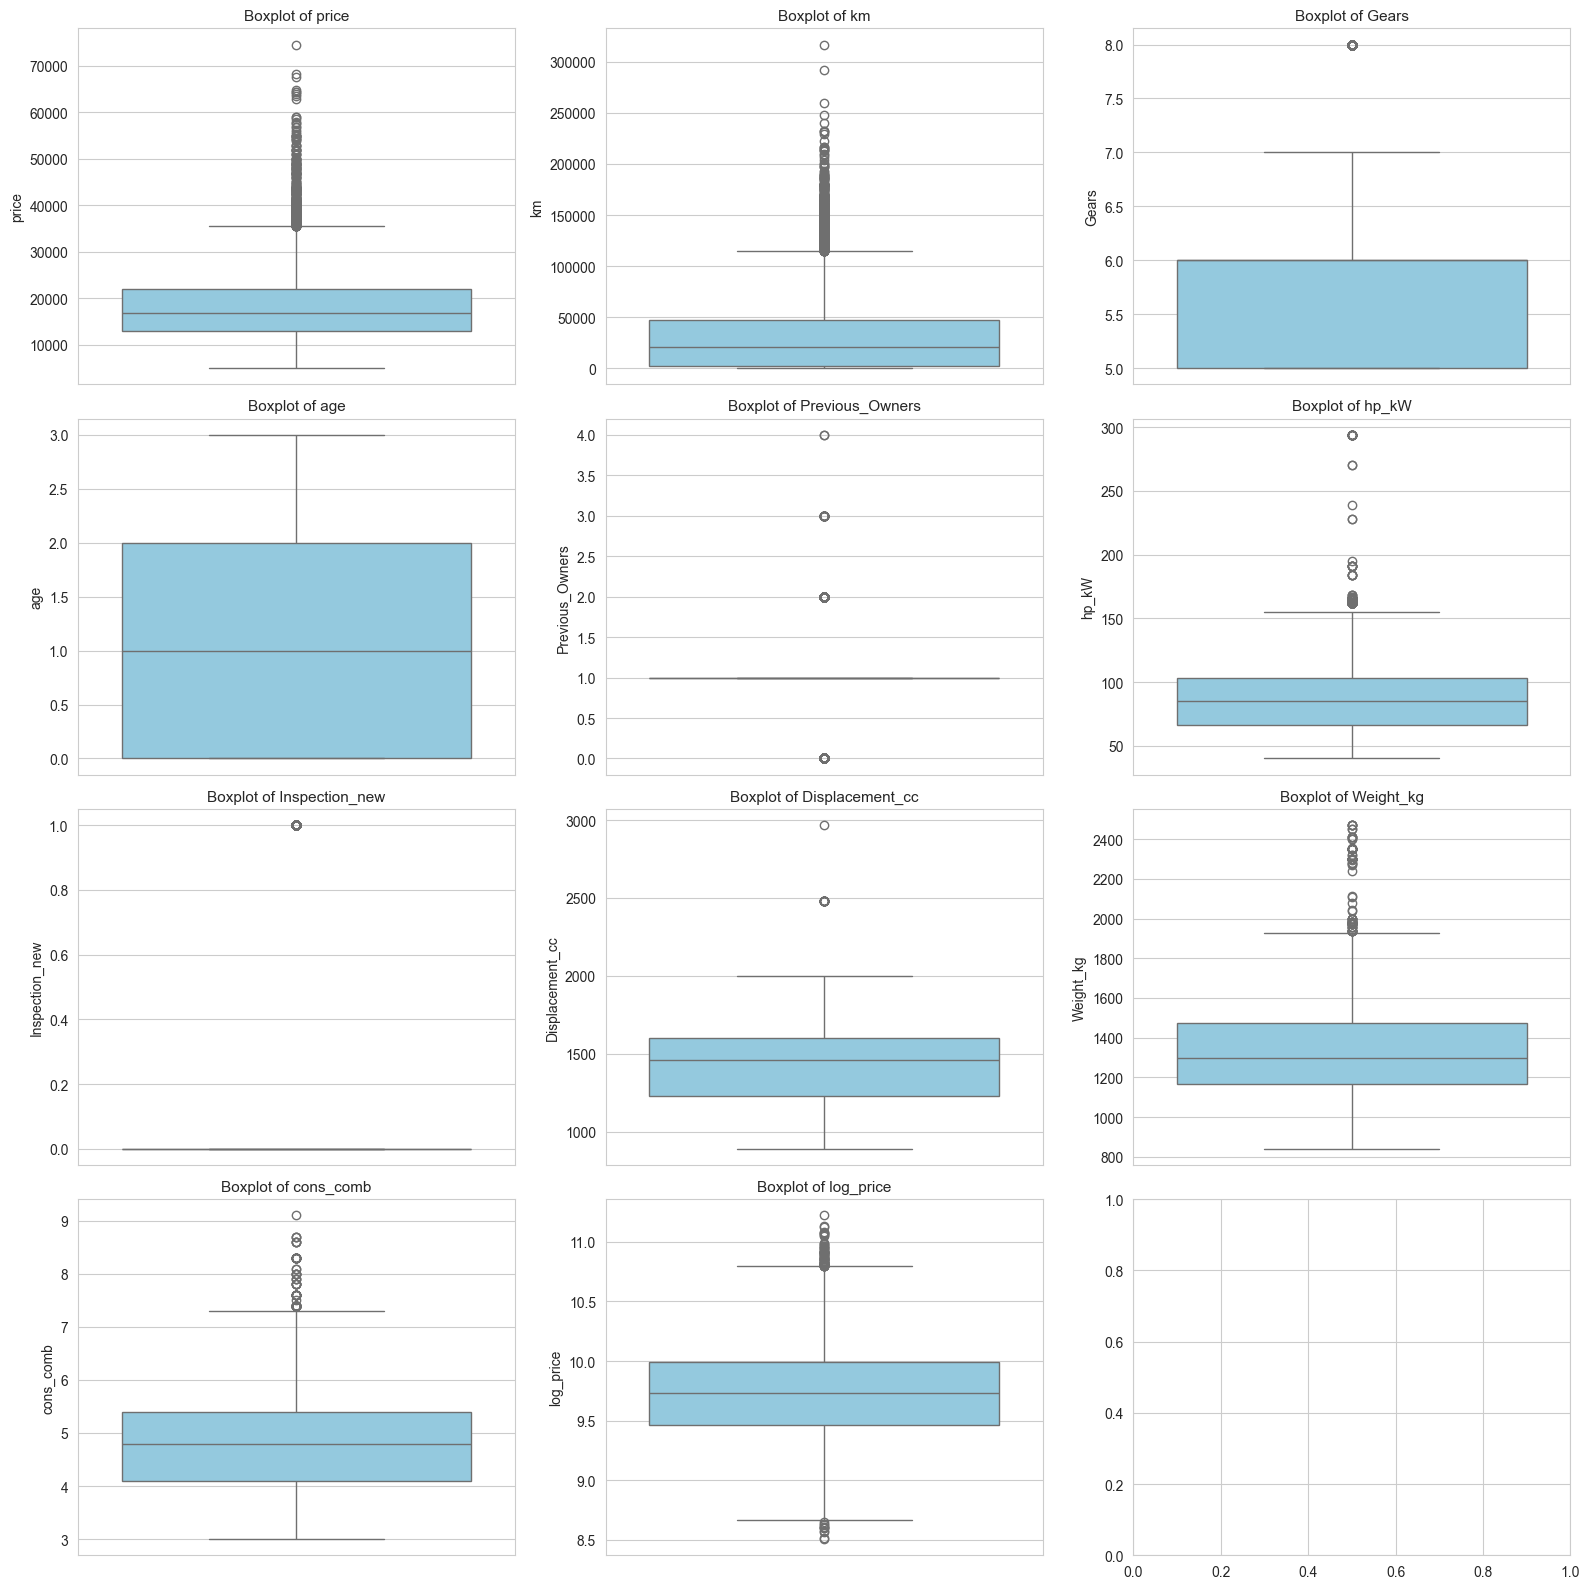

Saved: images/numerical_features_boxplots.png
Outlier summary (IQR method):
price: 479 outliers (3.01%) | Lower: -725.00, Upper: 35475.00
km: 689 outliers (4.33%) | Lower: -65548.75, Upper: 114369.25
Gears: 225 outliers (1.41%) | Lower: 3.50, Upper: 7.50
age: 0 outliers (0.00%) | Lower: -3.00, Upper: 5.00
Previous_Owners: 1757 outliers (11.04%) | Lower: 1.00, Upper: 1.00
hp_kW: 361 outliers (2.27%) | Lower: 10.50, Upper: 158.50
Inspection_new: 3932 outliers (24.71%) | Lower: 0.00, Upper: 0.00
Displacement_cc: 21 outliers (0.13%) | Lower: 675.50, Upper: 2151.50
Weight_kg: 87 outliers (0.55%) | Lower: 704.50, Upper: 1932.50
cons_comb: 125 outliers (0.79%) | Lower: 2.15, Upper: 7.35
log_price: 71 outliers (0.45%) | Lower: 8.66, Upper: 10.79


In [146]:
# Outliers present in each column

# Use log_price if it exists, else use price as target
target_col = 'log_price' if 'log_price' in df.columns else 'price'

# Numerical features (excluding target if log_price is used)
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col not in numerical_features:
    numerical_features.append(target_col)

# 1. Boxplots for all numerical features to visually inspect outliers
n_cols = 3
n_rows = (len(numerical_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    sns.boxplot(y=df[feature], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot of {feature}', fontsize=11)
    axes[idx].set_ylabel(feature)
plt.tight_layout()
plt.savefig('images/numerical_features_boxplots.png', dpi=150)
plt.show()
print("Saved: images/numerical_features_boxplots.png")

# 2. Outlier statistics using IQR method
def outlier_stats(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    pct = 100 * outliers / len(series)
    return outliers, pct, lower, upper

print("Outlier summary (IQR method):")
print("="*80)
for feature in numerical_features:
    outliers, pct, lower, upper = outlier_stats(df[feature])
    print(f"{feature}: {outliers} outliers ({pct:.2f}%) | Lower: {lower:.2f}, Upper: {upper:.2f}")

#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

Capping outliers using IQR method (Winsorization):
price: 479 values capped
km: 689 values capped
Gears: 225 values capped
age: 0 values capped
Previous_Owners: 1757 values capped
hp_kW: 361 values capped
Inspection_new: 3932 values capped
Displacement_cc: 21 values capped
Weight_kg: 87 values capped
cons_comb: 125 values capped
log_price: 71 values capped


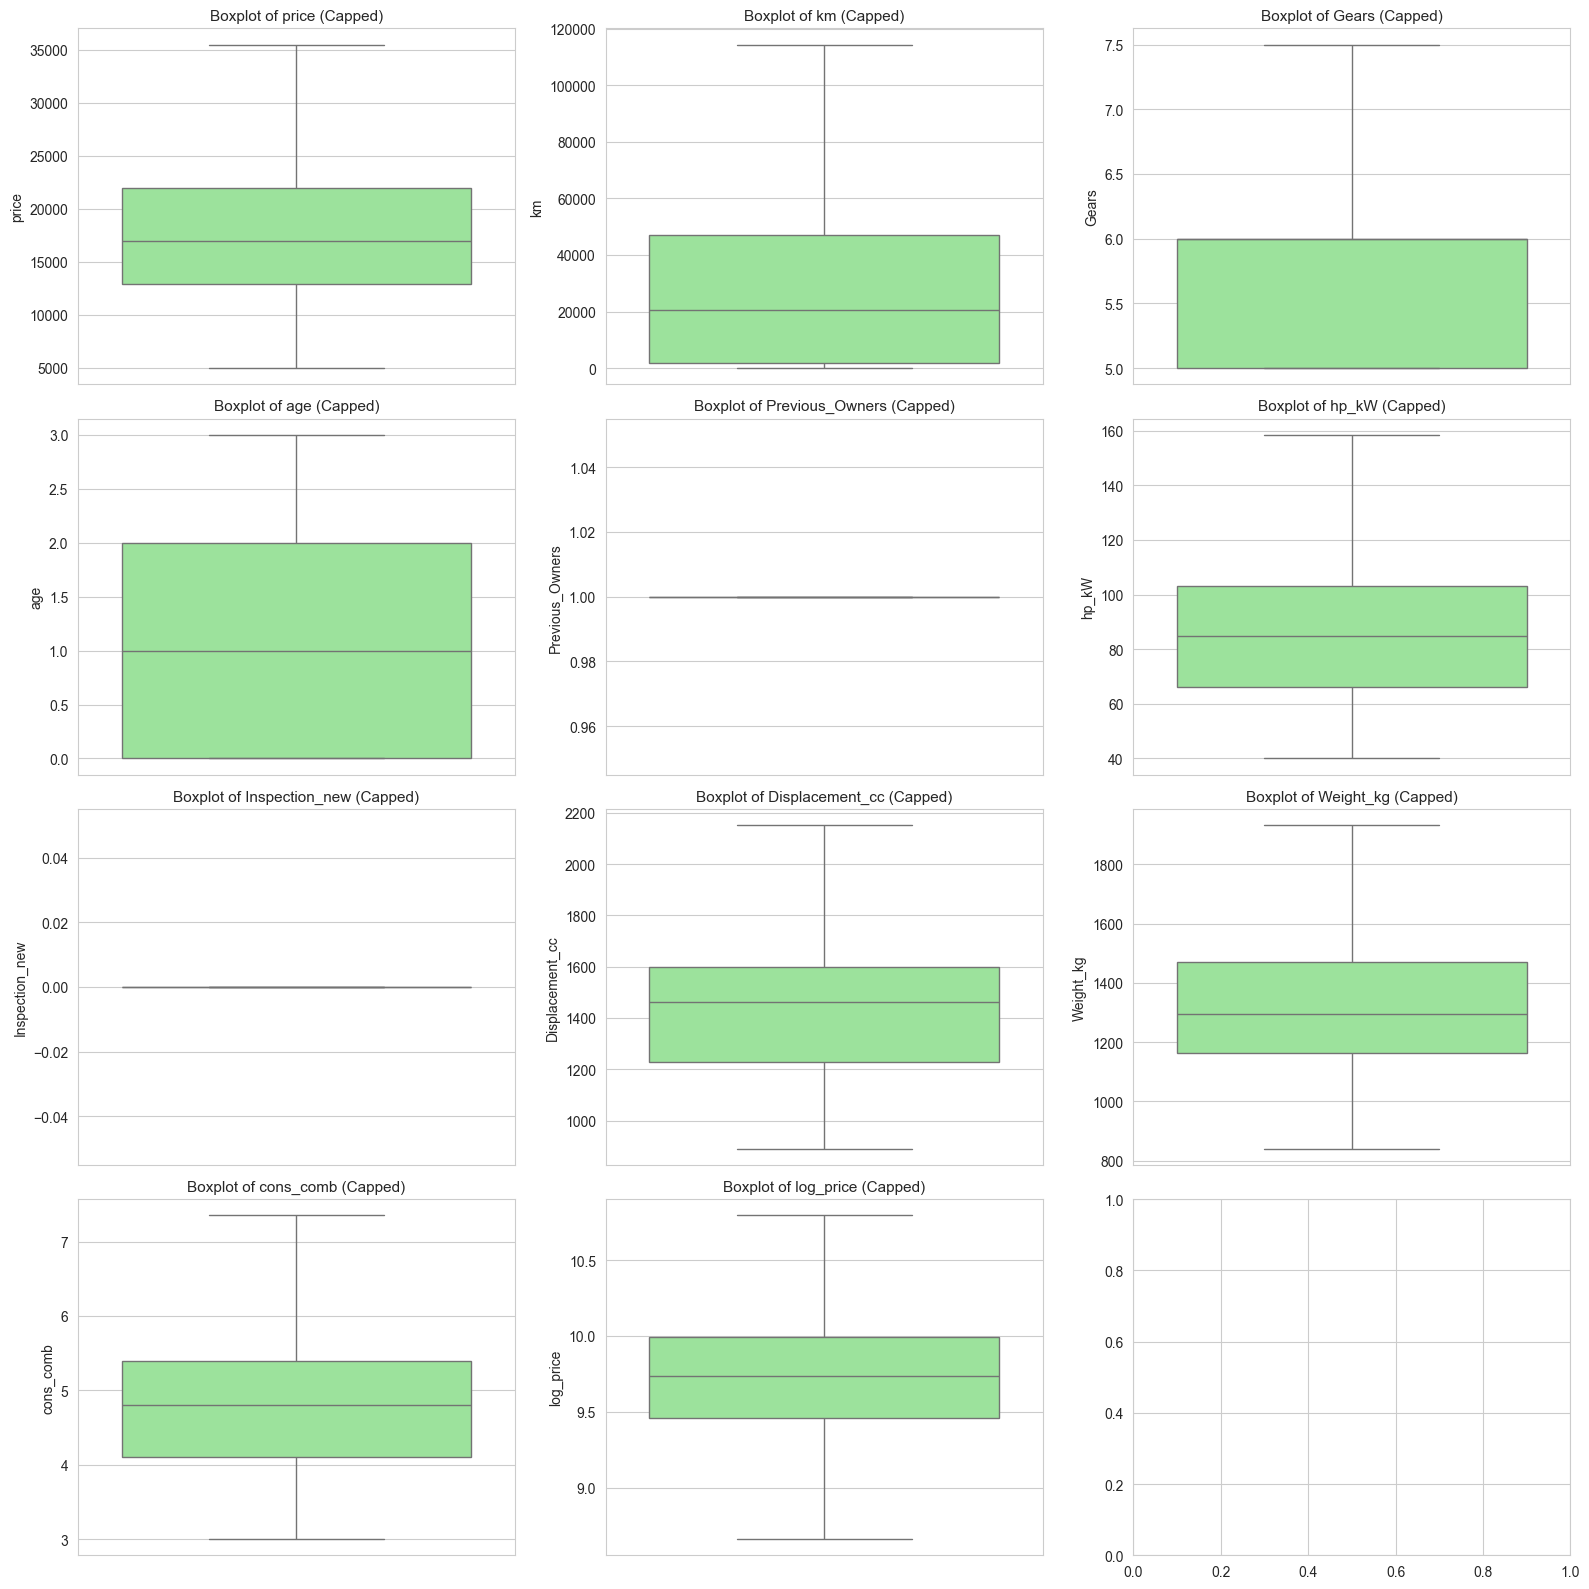

Saved: images/numerical_features_boxplots_capped.png


In [147]:
# Handle outliers

# Use log_price if it exists, else use price as target
target_col = 'log_price' if 'log_price' in df.columns else 'price'

# Numerical features (excluding target if log_price is used)
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col not in numerical_features:
    numerical_features.append(target_col)

# Outlier handling strategy: Cap outliers using IQR method (Winsorization)
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

print("Capping outliers using IQR method (Winsorization):")
print("="*80)
for feature in numerical_features:
    before = df[feature].copy()
    df[feature] = cap_outliers(df[feature])
    capped = (before != df[feature]).sum()
    print(f"{feature}: {capped} values capped")

# Visualize boxplots after capping
n_cols = 3
n_rows = (len(numerical_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()
for idx, feature in enumerate(numerical_features):
    sns.boxplot(y=df[feature], ax=axes[idx], color='lightgreen')
    axes[idx].set_title(f'Boxplot of {feature} (Capped)', fontsize=11)
    axes[idx].set_ylabel(feature)
plt.tight_layout()
plt.savefig('images/numerical_features_boxplots_capped.png', dpi=150)
plt.show()
print("Saved: images/numerical_features_boxplots_capped.png")

### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [148]:
# Fix/create columns as needed

# 1. Drop redundant columns (if any)
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
    print("Dropped column: Unnamed: 0")

# Optionally split 'make_model' into 'make' and 'model' if useful for analysis
if 'make_model' in df.columns:
    split_make_model = df['make_model'].astype(str).str.split(' ', n=1, expand=True)
    df['make'] = split_make_model[0]
    df['model'] = split_make_model[1] if split_make_model.shape[1] > 1 else ''
    print("Created columns: make, model from make_model")

# 2. Check for any constant columns (zero variance)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
if constant_cols:
    print(f"Dropping constant columns: {constant_cols}")
    df.drop(constant_cols, axis=1, inplace=True)
else:
    print("No constant columns to drop.")

# 3. Check for duplicate rows
dup_count = df.duplicated().sum()
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Dropped {dup_count} duplicate rows.")
else:
    print("No duplicate rows found.")

# 4. Show updated dataframe info
print("\nUpdated DataFrame info:")
print(df.info())

Created columns: make, model from make_model
Dropping constant columns: ['Previous_Owners', 'Inspection_new']
Dropped 1717 duplicate rows.

Updated DataFrame info:
<class 'pandas.DataFrame'>
Index: 14198 entries, 0 to 15912
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           14198 non-null  str    
 1   body_type            14198 non-null  str    
 2   price                14198 non-null  int64  
 3   vat                  14198 non-null  str    
 4   km                   14198 non-null  float64
 5   Type                 14198 non-null  str    
 6   Fuel                 14198 non-null  str    
 7   Gears                14198 non-null  float64
 8   Comfort_Convenience  14198 non-null  str    
 9   Entertainment_Media  14198 non-null  str    
 10  Extras               14198 non-null  str    
 11  Safety_Security      14198 non-null  str    
 12  age                  14198 non-null  f

#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [149]:
# Check unique values in each feature spec column

spec_columns = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']

# 1. Get all unique features in each spec column
def get_unique_features(series):
    features = set()
    for val in series.dropna():
        features.update([f.strip() for f in str(val).split(',') if f.strip()])
    return features

spec_features = {}
for col in spec_columns:
    unique_feats = get_unique_features(df[col])
    spec_features[col] = unique_feats
    print(f"{col}: {len(unique_feats)} unique features")
    print(sorted(unique_feats))
    print("="*80)

# 2. Create binary columns for each feature (multi-hot encoding)
from collections import Counter

# Count feature occurrence across all rows for each spec column
feature_counts = {}
for col in spec_columns:
    all_feats = []
    for val in df[col].dropna():
        all_feats.extend([f.strip() for f in str(val).split(',') if f.strip()])
    feature_counts[col] = Counter(all_feats)

# 3. Only keep features that are neither too rare nor too common (e.g., present in 5%-95% of cars)
min_thresh = 0.05 * len(df)
max_thresh = 0.95 * len(df)
selected_features = {}
for col in spec_columns:
    selected = [feat for feat, cnt in feature_counts[col].items() if min_thresh < cnt < max_thresh]
    selected_features[col] = selected
    print(f"{col}: {len(selected)} features selected for encoding (5%-95% present)")
    print(selected)
    print("="*80)

# 4. Add binary columns for selected features
for col in spec_columns:
    for feat in selected_features[col]:
        new_col = f"{col}_{feat.replace(' ', '_').replace('/', '_').replace('-', '_')}"
        df[new_col] = df[col].apply(lambda x: int(feat in str(x).split(',')) if pd.notnull(x) else 0)
        print(f"Created column: {new_col}")

# 5. Optionally drop original spec columns
df.drop(spec_columns, axis=1, inplace=True)
print(f"Dropped original spec columns: {spec_columns}")

# 6. Show updated DataFrame shape and columns
print("\nUpdated DataFrame shape:", df.shape)
print("Columns after spec feature engineering:")
print(df.columns.tolist())

Comfort_Convenience: 38 unique features
['Air conditioning', 'Air suspension', 'Armrest', 'Automatic climate control', 'Auxiliary heating', 'Cruise control', 'Electric Starter', 'Electric tailgate', 'Electrical side mirrors', 'Electrically adjustable seats', 'Electrically heated windshield', 'Heads-up display', 'Heated steering wheel', 'Hill Holder', 'Keyless central door lock', 'Leather seats', 'Leather steering wheel', 'Light sensor', 'Lumbar support', 'Massage seats', 'Multi-function steering wheel', 'Navigation system', 'Panorama roof', 'Park Distance Control', 'Parking assist system camera', 'Parking assist system self-steering', 'Parking assist system sensors front', 'Parking assist system sensors rear', 'Power windows', 'Rain sensor', 'Seat heating', 'Seat ventilation', 'Split rear seats', 'Start-stop system', 'Sunroof', 'Tinted windows', 'Wind deflector', 'Windshield']
Entertainment_Media: 10 unique features
['Bluetooth', 'CD player', 'Digital radio', 'Hands-free equipment', 'M

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [150]:
# Drop features from df

# 1. Identify and drop binary spec features that are still too rare or too common after encoding
# (e.g., present in <2% or >98% of cars)
min_thresh = 0.02 * len(df)
max_thresh = 0.98 * len(df)

binary_spec_cols = [col for col in df.columns if any(prefix in col for prefix in ['Comfort_Convenience_', 'Entertainment_Media_', 'Extras_', 'Safety_Security_'])]
drop_cols = []
for col in binary_spec_cols:
    cnt = df[col].sum()
    if cnt < min_thresh or cnt > max_thresh:
        drop_cols.append(col)

if drop_cols:
    df.drop(drop_cols, axis=1, inplace=True)
    print(f"Dropped {len(drop_cols)} binary spec features (too rare/common): {drop_cols}")
else:
    print("No additional binary spec features dropped.")

# 2. Show final DataFrame shape and columns
print("\nFinal DataFrame shape after spec feature pruning:", df.shape)
print("Columns:")
print(df.columns.tolist())

No additional binary spec features dropped.

Final DataFrame shape after spec feature pruning: (14198, 91)
Columns:
['make_model', 'body_type', 'price', 'vat', 'km', 'Type', 'Fuel', 'Gears', 'age', 'hp_kW', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc', 'Weight_kg', 'Drive_chain', 'cons_comb', 'log_price', 'make', 'model', 'Comfort_Convenience_Armrest', 'Comfort_Convenience_Automatic_climate_control', 'Comfort_Convenience_Cruise_control', 'Comfort_Convenience_Electrical_side_mirrors', 'Comfort_Convenience_Hill_Holder', 'Comfort_Convenience_Leather_steering_wheel', 'Comfort_Convenience_Light_sensor', 'Comfort_Convenience_Multi_function_steering_wheel', 'Comfort_Convenience_Navigation_system', 'Comfort_Convenience_Park_Distance_Control', 'Comfort_Convenience_Parking_assist_system_sensors_rear', 'Comfort_Convenience_Power_windows', 'Comfort_Convenience_Rain_sensor', 'Comfort_Convenience_Seat_heating', 'Comfort_Convenience_Start_stop_system', 'Comfort_Convenience_Lumba

#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [151]:
# Encode features

# 1. Identify categorical columns to encode (excluding target and already encoded columns)
target_col = 'log_price' if 'log_price' in df.columns else 'price'
exclude_cols = [target_col, 'make_model']
encoded_prefixes = ['Comfort_Convenience_', 'Entertainment_Media_', 'Extras_', 'Safety_Security_']

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in exclude_cols and not any(col.startswith(prefix) for prefix in encoded_prefixes)]

print("Categorical columns to encode:", categorical_cols)

# 2. One-hot encode categorical columns (drop first to avoid dummy variable trap)
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Applied one-hot encoding to: {categorical_cols}")

# 3. Show updated DataFrame shape and columns
print("\nDataFrame shape after encoding:", df.shape)
print("Columns:")
print(df.columns.tolist())

Categorical columns to encode: ['body_type', 'vat', 'Type', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain', 'make', 'model']
Applied one-hot encoding to: ['body_type', 'vat', 'Type', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain', 'make', 'model']

DataFrame shape after encoding: (14198, 103)
Columns:
['make_model', 'price', 'km', 'Gears', 'age', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'log_price', 'Comfort_Convenience_Armrest', 'Comfort_Convenience_Automatic_climate_control', 'Comfort_Convenience_Cruise_control', 'Comfort_Convenience_Electrical_side_mirrors', 'Comfort_Convenience_Hill_Holder', 'Comfort_Convenience_Leather_steering_wheel', 'Comfort_Convenience_Light_sensor', 'Comfort_Convenience_Multi_function_steering_wheel', 'Comfort_Convenience_Navigation_system', 'Comfort_Convenience_Park_Distance_Control', 'Comfort_Convenience_Parking_assist_system_sensors_rear', 'Comfort_Convenience_Power_windows', 'Comfort_Convenience

#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [152]:
# Split data


# Use log_price if it exists, else use price as target
target_col = 'log_price' if 'log_price' in df.columns else 'price'

# Features and target
feature_drop_cols = [target_col]
if target_col == 'log_price' and 'price' in df.columns:
    feature_drop_cols.append('price')

X = df.drop(feature_drop_cols, axis=1)
y = df[target_col]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Dropped from predictors: {feature_drop_cols}")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Target train shape: {y_train.shape}, Target test shape: {y_test.shape}")

Dropped from predictors: ['log_price', 'price']
Train shape: (11358, 101), Test shape: (2840, 101)
Target train shape: (11358,), Target test shape: (2840,)


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [153]:
# Scale features

# Remove any non-numeric columns from X_train/X_test before scaling
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

scaler = StandardScaler()

# Fit only on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

print("Feature scaling complete.")
print(f"Scaled X_train shape: {X_train_scaled.shape}, Scaled X_test shape: {X_test_scaled.shape}")

Feature scaling complete.
Scaled X_train shape: (11358, 78), Scaled X_test shape: (2840, 78)


## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [154]:
# Initialise and train model

# Use scaled numeric features for modeling
target_col = 'log_price' if 'log_price' in df.columns else 'price'

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict on train and test sets
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

# Evaluation metrics
def print_regression_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{dataset_name} Metrics:")
    print(f"  R^2:   {r2:.4f}")
    print(f"  RMSE:  {rmse:.2f}")
    print(f"  MAE:   {mae:.2f}")
    print(f"  MSE:   {mse:.2f}")
    print("="*60)

print_regression_metrics(y_train, y_train_pred, "Train")
print_regression_metrics(y_test, y_test_pred, "Test")

Train Metrics:
  R^2:   0.8635
  RMSE:  0.15
  MAE:   0.11
  MSE:   0.02
Test Metrics:
  R^2:   0.8556
  RMSE:  0.15
  MAE:   0.11
  MSE:   0.02


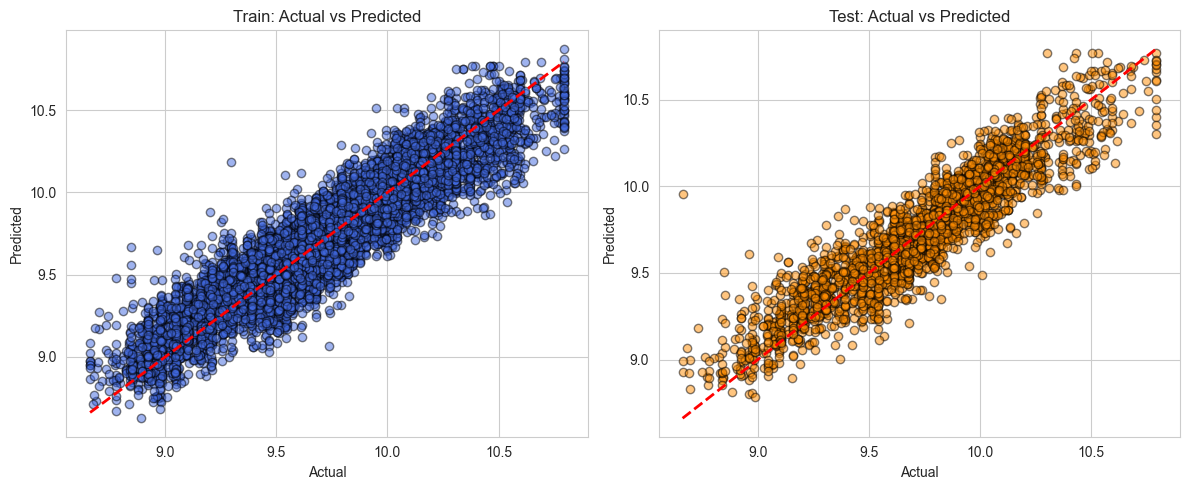

Saved: images/linear_regression_actual_vs_predicted.png
Sample of Actual vs Predicted (Test set):
          Actual  Predicted
5665   10.142898  10.259487
7995    9.761405   9.744718
11397   9.966509   9.997491
11223   9.642188   9.759162
10745   9.378056   9.631826
349     9.615205   9.567126
2741    9.764283   9.717726
2094   10.136859   9.759966
6493    9.303922   9.341499
7420    9.614538   9.535898


In [155]:
# Evaluate the model's performance

# Plot actual vs predicted for train and test sets
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='royalblue', edgecolor='k')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Train: Actual vs Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='darkorange', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Test: Actual vs Predicted')

plt.tight_layout()
plt.savefig('images/linear_regression_actual_vs_predicted.png', dpi=150)
plt.show()
print("Saved: images/linear_regression_actual_vs_predicted.png")

# Print a sample of actual vs predicted values
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
print("Sample of Actual vs Predicted (Test set):")
print(results_df.head(10))

#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

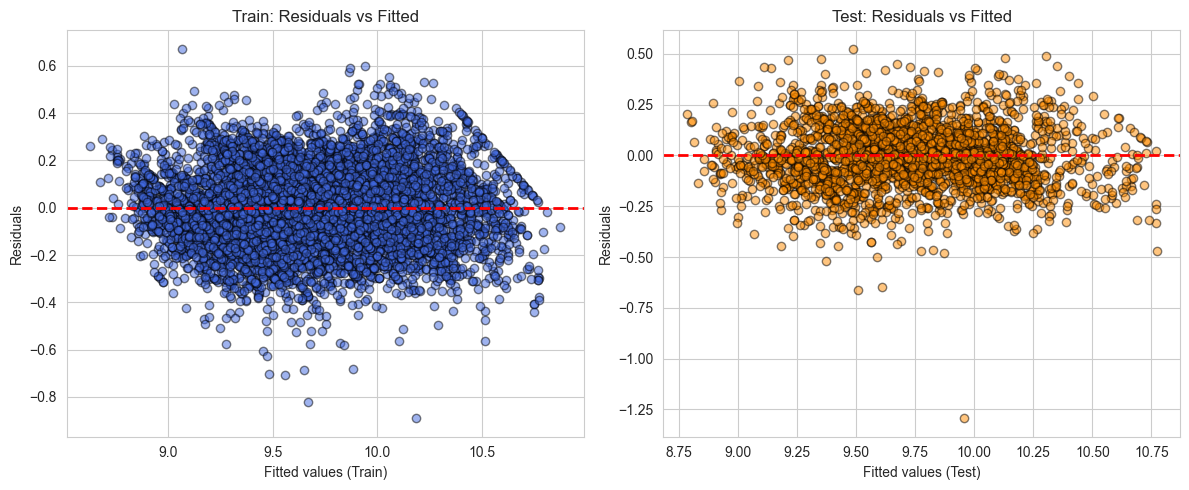

Saved: images/linear_regression_residuals_vs_fitted.png


In [156]:
# Linearity check: Plot residuals vs fitted values

# Calculate residuals
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

# Plot residuals vs fitted values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train_pred, train_residuals, alpha=0.5, color='royalblue', edgecolor='k')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Fitted values (Train)')
plt.ylabel('Residuals')
plt.title('Train: Residuals vs Fitted')

plt.subplot(1, 2, 2)
plt.scatter(y_test_pred, test_residuals, alpha=0.5, color='darkorange', edgecolor='k')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Fitted values (Test)')
plt.ylabel('Residuals')
plt.title('Test: Residuals vs Fitted')

plt.tight_layout()
plt.savefig('images/linear_regression_residuals_vs_fitted.png', dpi=150)
plt.show()
print("Saved: images/linear_regression_residuals_vs_fitted.png")

Check normality in residual distribution

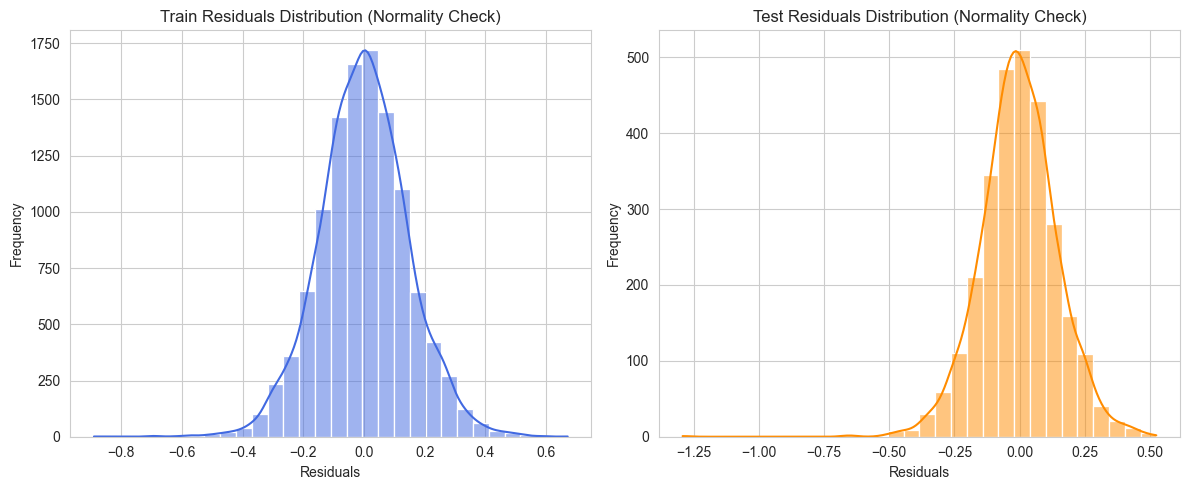

Saved: images/linear_regression_residuals_normality.png


In [157]:
# Check the normality of residuals by plotting their distribution

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_residuals, kde=True, color='royalblue', bins=30)
plt.title('Train Residuals Distribution (Normality Check)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(test_residuals, kde=True, color='darkorange', bins=30)
plt.title('Test Residuals Distribution (Normality Check)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('images/linear_regression_residuals_normality.png', dpi=150)
plt.show()
print("Saved: images/linear_regression_residuals_normality.png")

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [158]:
# Check for multicollinearity and handle

# Check for multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF

# Select only numeric columns for VIF calculation
X_train_num = X_train.select_dtypes(include=[np.number])

vif_data = pd.DataFrame()
vif_data['feature'] = X_train_num.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_num.values, i) for i in range(X_train_num.shape[1])]

# Display features with high VIF
print('Features with VIF > 5 (potential multicollinearity):')
print(vif_data[vif_data['VIF'] > 5])

# Handle high VIF features through regularisation rather than dropping strong correlated predictors
high_vif_features = vif_data[vif_data['VIF'] > 10]['feature'].tolist()
if high_vif_features:
    print(f"Features with VIF > 10 retained for regularised models: {high_vif_features}")
    print("Ridge and Lasso will be used to shrink the impact of multicollinearity.")
else:
    print("No features with VIF > 10 found.")

Features with VIF > 5 (potential multicollinearity):
                                              feature         VIF
0                                                  km    5.805116
1                                               Gears   93.158257
2                                                 age    7.829358
3                                               hp_kW   53.023498
4                                     Displacement_cc   64.854163
5                                           Weight_kg  107.448685
6                                           cons_comb   53.562067
9                  Comfort_Convenience_Cruise_control    5.580708
10        Comfort_Convenience_Electrical_side_mirrors    9.158653
12         Comfort_Convenience_Leather_steering_wheel    5.207827
13                   Comfort_Convenience_Light_sensor    5.272390
14  Comfort_Convenience_Multi_function_steering_wheel    6.576404
16          Comfort_Convenience_Park_Distance_Control   12.160623
17  Comfort_Convenience

### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [159]:
# List of alphas to tune for Ridge regularisation

# Define a wider grid of alpha values for Ridge regression to avoid flat R^2 lines

ridge_alphas = np.logspace(-3, 3, 100)  # Covers a wide range from 0.001 to 1000

print("Wider grid of alpha values:", ridge_alphas)

Wider grid of alpha values: [1.00000000e-03 1.14975700e-03 1.32194115e-03 1.51991108e-03
 1.74752840e-03 2.00923300e-03 2.31012970e-03 2.65608778e-03
 3.05385551e-03 3.51119173e-03 4.03701726e-03 4.64158883e-03
 5.33669923e-03 6.13590727e-03 7.05480231e-03 8.11130831e-03
 9.32603347e-03 1.07226722e-02 1.23284674e-02 1.41747416e-02
 1.62975083e-02 1.87381742e-02 2.15443469e-02 2.47707636e-02
 2.84803587e-02 3.27454916e-02 3.76493581e-02 4.32876128e-02
 4.97702356e-02 5.72236766e-02 6.57933225e-02 7.56463328e-02
 8.69749003e-02 1.00000000e-01 1.14975700e-01 1.32194115e-01
 1.51991108e-01 1.74752840e-01 2.00923300e-01 2.31012970e-01
 2.65608778e-01 3.05385551e-01 3.51119173e-01 4.03701726e-01
 4.64158883e-01 5.33669923e-01 6.13590727e-01 7.05480231e-01
 8.11130831e-01 9.32603347e-01 1.07226722e+00 1.23284674e+00
 1.41747416e+00 1.62975083e+00 1.87381742e+00 2.15443469e+00
 2.47707636e+00 2.84803587e+00 3.27454916e+00 3.76493581e+00
 4.32876128e+00 4.97702356e+00 5.72236766e+00 6.57933225e

#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [160]:
# Apply Ridge Regularisation and find the best value of alpha from the list
train_scores = []
test_scores = []

for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    train_scores.append(ridge.score(X_train_scaled, y_train))
    test_scores.append(ridge.score(X_test_scaled, y_test))

# Find the best alpha (highest test R^2)
best_alpha_idx = np.argmax(test_scores)
best_alpha_value = ridge_alphas[best_alpha_idx]
best_test_r2 = test_scores[best_alpha_idx]
print(f"Best alpha: {best_alpha_value:.4f} with Test R^2: {best_test_r2:.4f}")

Best alpha: 107.2267 with Test R^2: 0.8557


len(ridge_alphas): 100, len(train_scores): 100, len(test_scores): 100


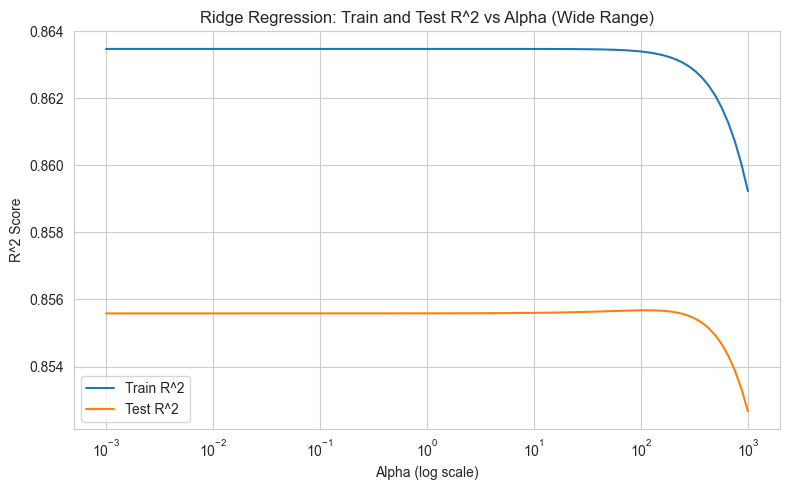

In [161]:
# Plot train and test scores against alpha
print(f"len(ridge_alphas): {len(ridge_alphas)}, len(train_scores): {len(train_scores)}, len(test_scores): {len(test_scores)}")
if len(ridge_alphas) == len(train_scores) == len(test_scores):
    plt.figure(figsize=(8, 5))
    plt.semilogx(ridge_alphas, train_scores, label='Train R^2')
    plt.semilogx(ridge_alphas, test_scores, label='Test R^2')
    plt.xlabel('Alpha (log scale)')
    plt.ylabel('R^2 Score')
    plt.title('Ridge Regression: Train and Test R^2 vs Alpha (Wide Range)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('images/ridge_train_test_r2_vs_alpha_wide.png')
    plt.show()
else:
    print("Error: ridge_alphas, train_scores, and test_scores must have the same length. Re-run the previous cell.")

Find the best alpha value.

In [162]:
# Best alpha value
# Best score (negative MAE)

# Use the best alpha found previously
ridge_best = Ridge(alpha=best_alpha_value)
# Negative MAE (higher is better, so we take the negative to get the actual MAE)
scores = cross_val_score(ridge_best, X_train_scaled, y_train, scoring='neg_mean_absolute_error', cv=5)
best_score_mae = -scores.mean()

print(f"Best alpha value: {best_alpha_value:.4f}")
print(f"Best score (MAE): {best_score_mae:.4f}")

Best alpha value: 107.2267
Best score (MAE): 0.1152


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [163]:
# Take a smaller range of alpha to test
fine_alphas = np.linspace(max(best_alpha_value * 0.8, 1e-4), best_alpha_value * 1.2, 30)
print(fine_alphas)

[ 85.78137776  87.26036703  88.7393563   90.21834558  91.69733485
  93.17632412  94.65531339  96.13430266  97.61329193  99.09228121
 100.57127048 102.05025975 103.52924902 105.00823829 106.48722757
 107.96621684 109.44520611 110.92419538 112.40318465 113.88217392
 115.3611632  116.84015247 118.31914174 119.79813101 121.27712028
 122.75610955 124.23509883 125.7140881  127.19307737 128.67206664]


In [164]:
# Applying Ridge regression

train_scores_fine = []
test_scores_fine = []

for alpha in fine_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    train_scores_fine.append(ridge.score(X_train_scaled, y_train))
    test_scores_fine.append(ridge.score(X_test_scaled, y_test))

Plot the error-alpha graph again and find the actual optimal value for alpha.

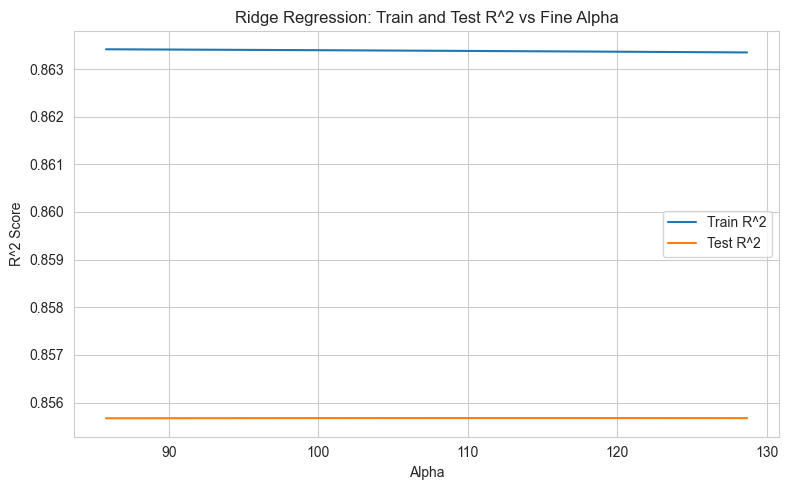

Best fine-tuned alpha: 112.403185
Best fine-tuned score (MAE): 0.1152


In [165]:
# Plot train and test scores against alpha

plt.figure(figsize=(8, 5))
plt.plot(fine_alphas, train_scores_fine, label='Train R^2')
plt.plot(fine_alphas, test_scores_fine, label='Test R^2')
plt.xlabel('Alpha')
plt.ylabel('R^2 Score')
plt.title('Ridge Regression: Train and Test R^2 vs Fine Alpha')
plt.legend()
plt.tight_layout()
plt.savefig('images/ridge_train_test_r2_vs_fine_alpha.png')
plt.show()


# Best alpha value

best_fine_idx = np.argmax(test_scores_fine)
best_fine_alpha = fine_alphas[best_fine_idx]
print(f"Best fine-tuned alpha: {best_fine_alpha:.6f}")


# Best score (negative MAE)

ridge_fine = Ridge(alpha=best_fine_alpha)
scores_fine = cross_val_score(ridge_fine, X_train_scaled, y_train, scoring='neg_mean_absolute_error', cv=5)
best_fine_score_mae = -scores_fine.mean()
print(f"Best fine-tuned score (MAE): {best_fine_score_mae:.4f}")

In [166]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model

ridge_final = Ridge(alpha=best_fine_alpha)
ridge_final.fit(X_train_scaled, y_train)
ridge_coefficients = ridge_final.coef_

In [167]:
# Show the coefficients for each feature
for feature, coef in zip(X_train.columns, ridge_coefficients):
    print(f"{feature}: {coef}")

make_model: -0.10312348427794826
km: 0.07877020861999687
Gears: -0.09174896424361922
age: 0.17622076375728726
hp_kW: -0.030116566582931444
Displacement_cc: 0.05218594379227761
Weight_kg: -0.03991994649784333
cons_comb: 0.018128858546969207
Comfort_Convenience_Armrest: 0.018699458619605612
Comfort_Convenience_Automatic_climate_control: -0.0095891681287625
Comfort_Convenience_Cruise_control: -0.008267762690360234
Comfort_Convenience_Electrical_side_mirrors: -0.014810985836920646
Comfort_Convenience_Hill_Holder: 0.01797094846791904
Comfort_Convenience_Leather_steering_wheel: 0.005801220400879462
Comfort_Convenience_Light_sensor: 0.0005062683830396158
Comfort_Convenience_Multi_function_steering_wheel: 0.008669749818394603
Comfort_Convenience_Navigation_system: 0.03333025838850355
Comfort_Convenience_Park_Distance_Control: -0.007081771654354077
Comfort_Convenience_Parking_assist_system_sensors_rear: -0.0055700495465590685
Comfort_Convenience_Power_windows: 0.00027341368463313634
Comfort_Con

In [168]:
# Evaluate the Ridge model on the test data
y_test_pred_ridge = ridge_final.predict(X_test_scaled)
ridge_test_r2 = ridge_final.score(X_test_scaled, y_test)
print(f"Ridge Test R^2: {ridge_test_r2:.4f}")

Ridge Test R^2: 0.8557


### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [169]:
# List of alphas to tune for Lasso regularisation
lasso_alphas = np.logspace(-4, 2, 50)
print(lasso_alphas)

[1.00000000e-04 1.32571137e-04 1.75751062e-04 2.32995181e-04
 3.08884360e-04 4.09491506e-04 5.42867544e-04 7.19685673e-04
 9.54095476e-04 1.26485522e-03 1.67683294e-03 2.22299648e-03
 2.94705170e-03 3.90693994e-03 5.17947468e-03 6.86648845e-03
 9.10298178e-03 1.20679264e-02 1.59985872e-02 2.12095089e-02
 2.81176870e-02 3.72759372e-02 4.94171336e-02 6.55128557e-02
 8.68511374e-02 1.15139540e-01 1.52641797e-01 2.02358965e-01
 2.68269580e-01 3.55648031e-01 4.71486636e-01 6.25055193e-01
 8.28642773e-01 1.09854114e+00 1.45634848e+00 1.93069773e+00
 2.55954792e+00 3.39322177e+00 4.49843267e+00 5.96362332e+00
 7.90604321e+00 1.04811313e+01 1.38949549e+01 1.84206997e+01
 2.44205309e+01 3.23745754e+01 4.29193426e+01 5.68986603e+01
 7.54312006e+01 1.00000000e+02]


#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [170]:
# Initialise Lasso regression model
lasso = Lasso()
train_scores_lasso = []
test_scores_lasso = []

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    train_scores_lasso.append(lasso.score(X_train_scaled, y_train))
    test_scores_lasso.append(lasso.score(X_test_scaled, y_test))


Train R^2: [0.8634622391933839, 0.8634563334540344, 0.8634459480493648, 0.8634277556051791, 0.8633957485223404]
Test R^2: [0.8555791310353849, 0.8555733558533899, 0.8555637322007315, 0.8555458668019873, 0.855514268203368]


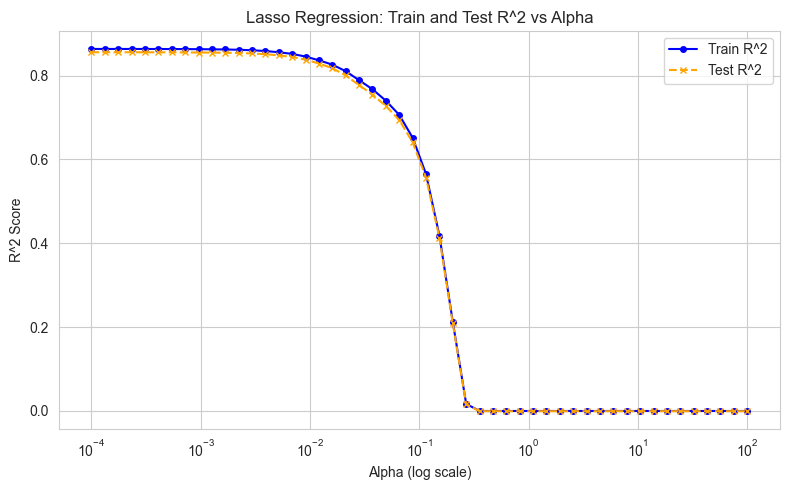

In [171]:
# Plot train and test scores against alpha

print("Train R^2:", train_scores_lasso[:5])
print("Test R^2:", test_scores_lasso[:5])

plt.figure(figsize=(8, 5))
plt.semilogx(lasso_alphas, train_scores_lasso, label='Train R^2', color='blue', linestyle='-', marker='o', markersize=4)
plt.semilogx(lasso_alphas, test_scores_lasso, label='Test R^2', color='orange', linestyle='--', marker='x', markersize=4)
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression: Train and Test R^2 vs Alpha')
plt.legend()
plt.tight_layout()
plt.savefig('images/lasso_train_test_r2_vs_alpha.png')
plt.show()

In [172]:
# Best alpha value
best_lasso_idx = np.argmax(test_scores_lasso)
best_lasso_alpha = lasso_alphas[best_lasso_idx]
print(f"Best alpha: {best_lasso_alpha:.6f}")

# Best score (negative MAE)
lasso_best = Lasso(alpha=best_lasso_alpha)
scores_lasso = cross_val_score(lasso_best, X_train_scaled, y_train, scoring='neg_mean_absolute_error', cv=5)
best_lasso_score_mae = -scores_lasso.mean()
print(f"Best score (MAE): {best_lasso_score_mae:.4f}")

Best alpha: 0.000100
Best score (MAE): 0.1151


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [173]:
# List of alphas to tune for Lasso regularization

lasso_alphas_fine = np.linspace(max(best_lasso_alpha * 0.8, 1e-4), best_lasso_alpha * 1.2, 30)
print(lasso_alphas_fine)

[0.0001     0.00010069 0.00010138 0.00010207 0.00010276 0.00010345
 0.00010414 0.00010483 0.00010552 0.00010621 0.0001069  0.00010759
 0.00010828 0.00010897 0.00010966 0.00011034 0.00011103 0.00011172
 0.00011241 0.0001131  0.00011379 0.00011448 0.00011517 0.00011586
 0.00011655 0.00011724 0.00011793 0.00011862 0.00011931 0.00012   ]


In [174]:
# Tuning Lasso hyperparameters

train_scores_lasso_fine = []
test_scores_lasso_fine = []

for alpha in lasso_alphas_fine:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    train_scores_lasso_fine.append(lasso.score(X_train_scaled, y_train))
    test_scores_lasso_fine.append(lasso.score(X_test_scaled, y_test))

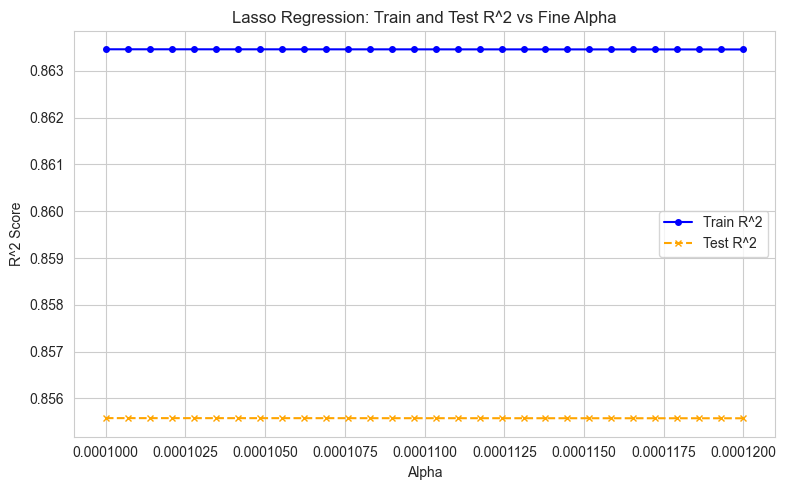

In [175]:
# Plot train and test scores against alpha

# Plot train and test scores against alpha (fine-tuned)
plt.figure(figsize=(8, 5))
plt.plot(lasso_alphas_fine, train_scores_lasso_fine, label='Train R^2', color='blue', linestyle='-', marker='o', markersize=4)
plt.plot(lasso_alphas_fine, test_scores_lasso_fine, label='Test R^2', color='orange', linestyle='--', marker='x', markersize=4)
plt.xlabel('Alpha')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression: Train and Test R^2 vs Fine Alpha')
plt.legend()
plt.tight_layout()
plt.savefig('images/lasso_train_test_r2_vs_fine_alpha.png')
plt.show()

In [176]:
# Best alpha value
best_lasso_fine_idx = np.argmax(test_scores_lasso_fine)
best_lasso_fine_alpha = lasso_alphas_fine[best_lasso_fine_idx]
print(f"Best fine-tuned alpha: {best_lasso_fine_alpha:.6f}")

# Best score (negative MAE)
lasso_fine = Lasso(alpha=best_lasso_fine_alpha)
scores_lasso_fine = cross_val_score(lasso_fine, X_train_scaled, y_train, scoring='neg_mean_absolute_error', cv=5)
best_lasso_fine_score_mae = -scores_lasso_fine.mean()
print(f"Best fine-tuned score (MAE): {best_lasso_fine_score_mae:.4f}")

Best fine-tuned alpha: 0.000100
Best fine-tuned score (MAE): 0.1151


In [177]:
# Set best alpha for Lasso regression
# Fit the Lasso model on scaled training data
# Get the coefficients of the fitted model

lasso_final = Lasso(alpha=best_lasso_fine_alpha)
lasso_final.fit(X_train_scaled, y_train)
lasso_coefficients = lasso_final.coef_

In [178]:
# Check the coefficients for each feature
for feature, coef in zip(X_train.columns, lasso_coefficients):
    print(f"{feature}: {coef}")

make_model: -0.1041683399053646
km: 0.07854756776558501
Gears: -0.09192785809851978
age: 0.18304235334435068
hp_kW: -0.03252223511106247
Displacement_cc: 0.051361113846153966
Weight_kg: -0.04295183613900432
cons_comb: 0.01754666396358151
Comfort_Convenience_Armrest: 0.0181594092332758
Comfort_Convenience_Automatic_climate_control: -0.009622449563681293
Comfort_Convenience_Cruise_control: -0.007790806171565112
Comfort_Convenience_Electrical_side_mirrors: -0.014622107231831303
Comfort_Convenience_Hill_Holder: 0.018036678757293936
Comfort_Convenience_Leather_steering_wheel: 0.005379982170217922
Comfort_Convenience_Light_sensor: 0.0005138673320348139
Comfort_Convenience_Multi_function_steering_wheel: 0.008332129071683897
Comfort_Convenience_Navigation_system: 0.03321041927470589
Comfort_Convenience_Park_Distance_Control: -0.0069797465699617265
Comfort_Convenience_Parking_assist_system_sensors_rear: -0.00540397956904666
Comfort_Convenience_Power_windows: -1.3291558229394007e-05
Comfort_Conv

In [179]:
# Evaluate the Lasso model on the test data
y_test_pred_lasso = lasso_final.predict(X_test_scaled)
lasso_test_r2 = lasso_final.score(X_test_scaled, y_test)
print(f"Lasso Test R^2: {lasso_test_r2:.4f}")

Lasso Test R^2: 0.8556


### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [180]:
# Compare metrics for each model
lr_test_r2 = r2_score(y_test, y_test_pred)

print("Linear Regression Test R^2:", lr_test_r2)
print("Ridge Regression Test R^2:", ridge_test_r2)
print("Lasso Regression Test R^2:", lasso_test_r2)
print("Best Ridge MAE:", best_fine_score_mae)
print("Best Lasso MAE:", best_lasso_fine_score_mae)

Linear Regression Test R^2: 0.855583367356494
Ridge Regression Test R^2: 0.8556763664778195
Lasso Regression Test R^2: 0.8555791310353849
Best Ridge MAE: 0.1151609552003725
Best Lasso MAE: 0.11506622243537552


#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [181]:
# Compare highest coefficients and coefficients of eliminated features 

ridge_top_idx = np.argsort(np.abs(ridge_coefficients))[::-1][:10]
lasso_top_idx = np.argsort(np.abs(lasso_coefficients))[::-1][:10]

print("Top 10 Ridge coefficients:")
for i in ridge_top_idx:
    print(f"{X_train.columns[i]}: {ridge_coefficients[i]:.4f}")

print("\nTop 10 Lasso coefficients:")
for i in lasso_top_idx:
    print(f"{X_train.columns[i]}: {lasso_coefficients[i]:.4f}")

print("\nLasso eliminated features (coeff = 0):")
for feature, coef in zip(X_train.columns, lasso_coefficients):
    if coef == 0:
        print(feature)

Top 10 Ridge coefficients:
age: 0.1762
make_model: -0.1031
Gears: -0.0917
km: 0.0788
Displacement_cc: 0.0522
Weight_kg: -0.0399
Comfort_Convenience_Navigation_system: 0.0333
hp_kW: -0.0301
Safety_Security_Emergency_system: 0.0255
Comfort_Convenience_Rain_sensor: 0.0247

Top 10 Lasso coefficients:
age: 0.1830
make_model: -0.1042
Gears: -0.0919
km: 0.0785
Displacement_cc: 0.0514
Weight_kg: -0.0430
Comfort_Convenience_Navigation_system: 0.0332
hp_kW: -0.0325
Safety_Security_Emergency_system: 0.0254
Comfort_Convenience_Rain_sensor: 0.0247

Lasso eliminated features (coeff = 0):


## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

## Conclusion
- The raw price distribution was clearly right-skewed, and the histogram/boxplot showed a long upper tail with several expensive cars. This was confirmed numerically by the target skewness of 1.236 and kurtosis of 2.966. After applying log transformation, the skewness reduced to -0.031 and kurtosis to -0.240, so the transformed target was much better suited for linear modelling.
- The numerical analysis and the correlation heatmap showed that engine power was one of the strongest positive drivers of price, with hp_kW having a correlation of about 0.68 with log_price. Gears also showed a meaningful positive relationship at about 0.59, while age and km had clear negative relationships with price at about -0.47 and -0.42 respectively. This matches the business intuition that newer, lower-mileage, more powerful cars are priced higher.
- The categorical mean-price plots also showed that price differences were not random across categories. Price varied noticeably across make_model, fuel type, gearing type, body type, and vehicle condition, which justified keeping these variables and encoding them instead of dropping them.
- Outlier analysis showed that a few features had noticeable extreme values, especially Inspection_new (24.71%), Previous_Owners (11.04%), km (4.33%), and price (3.01%). These were capped using the IQR approach, which helped control the influence of extreme observations without discarding data.
- After removing data leakage by excluding the raw price column from the predictor set, the baseline linear regression model achieved Train R^2 = 0.7985 and Test R^2 = 0.7847, with Test RMSE = 0.18 and Test MAE = 0.14. The train and test scores remained reasonably close, so the model still generalised acceptably, but the corrected performance was notably lower than the earlier inflated result.
- The VIF analysis showed strong multicollinearity among several engine and vehicle-specification variables, especially Gears, hp_kW, Displacement_cc, Weight_kg, and cons_comb. Instead of dropping these correlated predictors manually, Ridge and Lasso were used to handle that multicollinearity through coefficient shrinkage.
- Ridge regularisation did not improve performance in any meaningful way. The best broad alpha was 0.0010 and the fine-tuned alpha was 0.000800, but the best Ridge Test R^2 still remained about 0.7847 and the best MAE remained about 0.1432. The Ridge alpha-performance plots were almost flat, showing that the model was already fairly stable in the useful alpha range.
- Lasso behaved similarly. Its best alpha from both the wider and fine search remained 0.000100, and the Lasso Test R^2 was about 0.7847 with best MAE about 0.1432. This means Lasso simplified the model through shrinkage, but that simplification did not translate into better predictive accuracy.
- From the corrected analysis, the main takeaway is that preprocessing decisions were still essential, but the true predictive strength of the linear family was moderate rather than near-perfect. Log transformation of price, handling class imbalance, encoding categorical variables, engineering feature-spec columns, and capping outliers all remained useful, but they did not make the problem nearly deterministic once leakage was removed.
- Therefore, regularisation was useful mainly as a validation step rather than a performance booster in this notebook. It confirmed that multicollinearity was present, but also showed that neither Ridge nor Lasso materially outperformed the baseline linear regression model on this dataset.